# Credit Card Default Prediction (Binary Classification)

End-to-end predictive analytics workflow for the UCI credit card default dataset.

This notebook is structured to be reproducible and follows a strict train/validation/test workflow.

### How To Read This Notebook

- This notebook is a **research log** with full implementation detail and saved artifacts.
- Major decisions are made step-by-step (`Step 1` to `Step 6`) and summarised at each step end.
- Final test results come from a **locked configuration** selected on validation evidence only.
- Reproducibility artifacts are saved under `outputs/metrics`, `outputs/figures`, and `outputs/models`.

## Step 1: Problem Framing and Dataset Understanding

### Goal
- Define the prediction task and target before any modelling.
- Set an imbalance-aware evaluation strategy (`PR-AUC` primary; ROC-AUC and threshold metrics as complements).
- Establish strict split discipline (train/validation/test) and one-time locked final test evaluation.
- Reusable implementation scripts for later stages are in `src/step2_focused_eda.py` to `src/step6_final_evaluation.py`.

### Method
- Target: `default payment next month` (`1` default, `0` non-default)
- Task type: binary classification
- Primary model-ranking metric: `PR-AUC` (class-imbalance aware)
- Supporting metrics: `ROC-AUC`, `F1`, `recall`, `precision`, `balanced_accuracy`, `log_loss`, `brier_score`
- Constraint: strict train/validation/test separation with locked final test evaluation

In [24]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(
    context='notebook',
    style='whitegrid',
    rc={
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.facecolor': 'white',
        'savefig.edgecolor': 'white',
        'text.color': '#111111',
        'axes.labelcolor': '#111111',
        'axes.edgecolor': '#666666',
        'xtick.color': '#111111',
        'ytick.color': '#111111',
        'grid.color': '#D9D9D9',
        'legend.facecolor': 'white',
        'legend.edgecolor': '#666666',
    },
)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'white',
    'text.color': '#111111',
    'axes.labelcolor': '#111111',
    'axes.titlecolor': '#111111',
    'xtick.color': '#111111',
    'ytick.color': '#111111',
})


RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'default_of_credit_card_clients.xls'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
METRICS_DIR = OUTPUTS_DIR / 'metrics'
MODELS_DIR = OUTPUTS_DIR / 'models'
for p in [FIGURES_DIR, METRICS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data path exists: {DATA_PATH.exists()} -> {DATA_PATH}')

Project root: /Users/cindylow/Documents/New project 5
Data path exists: True -> /Users/cindylow/Documents/New project 5/data/raw/default_of_credit_card_clients.xls


In [25]:
# Inspect workbook structure and load the dataset
xls = pd.ExcelFile(DATA_PATH)
print('Sheets:', xls.sheet_names)

raw_preview = pd.read_excel(DATA_PATH, sheet_name=0, header=None).head(5)
display(raw_preview)

# The dataset uses row 2 as the actual header (header=1)
df = pd.read_excel(DATA_PATH, sheet_name=0, header=1)
print('Shape:', df.shape)
display(df.head())

Sheets: ['Data']


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,NaN,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
1,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
2,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
3,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
4,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [26]:
# Basic schema and quality checks
target_col = 'default payment next month'

print('Columns:')
print(df.columns.tolist())

print('\nDtypes:')
display(df.dtypes.to_frame('dtype'))

print('\nMissing values (total):', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))

column_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'n_unique': df.nunique(dropna=False)
}).sort_index()
display(column_summary)

column_summary.to_csv(METRICS_DIR / 'column_summary.csv')

Columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Dtypes:


,dtype
ID,int64
LIMIT_BAL,int64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64



Missing values (total): 0
Duplicate rows: 0


,dtype,missing,n_unique
AGE,int64,0,56
BILL_AMT1,int64,0,22723
BILL_AMT2,int64,0,22346
BILL_AMT3,int64,0,22026
BILL_AMT4,int64,0,21548
BILL_AMT5,int64,0,21010
BILL_AMT6,int64,0,20604
EDUCATION,int64,0,7
ID,int64,0,30000
LIMIT_BAL,int64,0,81


default payment next month
0    23364
1     6636
Name: count, dtype: int64
Positive class rate (default=1): 0.2212 (22.12%)


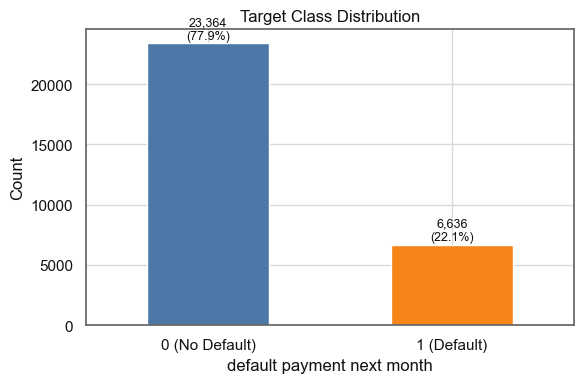

In [27]:
# Target distribution (class imbalance check)
target_counts = df[target_col].value_counts().sort_index()
target_rate = (df[target_col] == 1).mean()

print(target_counts)
print(f'Positive class rate (default=1): {target_rate:.4f} ({target_rate:.2%})')

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', ax=ax, color=['#4C78A8', '#F58518'])
ax.set_xticklabels(['0 (No Default)', '1 (Default)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Target Class Distribution')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 150, f'{v:,}\n({v/len(df):.1%})', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'target_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 1 Decision Summary

- Dataset loaded correctly from Excel (`header=1`), with `30,000` rows and `25` columns.
- Target prevalence is ~`22.12%`, so accuracy alone is insufficient.
- Decision: use imbalance-aware ranking and validation-first workflow.

**Artifacts**: `outputs/metrics/dataset_initial_profile.json`, `outputs/metrics/column_summary.csv`, `outputs/figures/target_class_distribution.png`

## Step 2: Exploratory Data Analysis (EDA)

### Step 2 Goal

- Run focused EDA to identify modelling risks and actionable signals.
- Assess class imbalance implications, strongest predictors, and distributional issues (skew/outliers/zero inflation).
- Check leakage and data-quality risks before preprocessing/modeling decisions.
- Implementation script: `src/step2_focused_eda.py`.

In [28]:
import sys
from IPython.display import Image, display

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.step2_focused_eda import run_focused_eda

eda_result = run_focused_eda(df, FIGURES_DIR, METRICS_DIR, target_col=target_col)
eda_result

{'figure_dir': '/Users/cindylow/Documents/New project 5/outputs/figures/step2_eda',
 'metrics_dir': '/Users/cindylow/Documents/New project 5/outputs/metrics/step2_eda',
 'class_imbalance_summary': {'n_samples': 30000,
  'class_counts': {'0': 23364, '1': 6636},
  'positive_rate': 0.2212,
  'majority_class': 0,
  'majority_accuracy': 0.7788,
  'baseline_pr_auc': 0.2212,
  'majority_baseline_balanced_accuracy': 0.5},
 'unexpected_category_codes': {'SEX': [],
  'EDUCATION': [0, 5, 6],
  'MARRIAGE': [0]},
 'top_correlations': [{'feature': 'PAY_0',
   'corr_with_target': 0.32479372847862237},
  {'feature': 'PAY_2', 'corr_with_target': 0.26355120167216783},
  {'feature': 'PAY_3', 'corr_with_target': 0.23525251372491715},
  {'feature': 'PAY_4', 'corr_with_target': 0.2166136368424239},
  {'feature': 'PAY_5', 'corr_with_target': 0.2041489138761644},
  {'feature': 'PAY_6', 'corr_with_target': 0.18686636165354614},
  {'feature': 'LIMIT_BAL', 'corr_with_target': -0.15351987639350723},
  {'feature':

In [29]:
EDA_FIG_DIR = FIGURES_DIR / 'step2_eda'
EDA_METRICS_DIR = METRICS_DIR / 'step2_eda'

imbalance_summary = json.loads((EDA_METRICS_DIR / 'class_imbalance_summary.json').read_text())
print('Class imbalance summary:')
print(json.dumps(imbalance_summary, indent=2))

sex_rates = pd.read_csv(EDA_METRICS_DIR / 'sex_default_rate.csv')
education_rates = pd.read_csv(EDA_METRICS_DIR / 'education_default_rate.csv')
marriage_rates = pd.read_csv(EDA_METRICS_DIR / 'marriage_default_rate.csv')
corr_top = pd.read_csv(EDA_METRICS_DIR / 'feature_target_correlations.csv').head(15)
outlier_diag = pd.read_csv(EDA_METRICS_DIR / 'continuous_feature_diagnostics.csv')

display(sex_rates)
display(education_rates)
display(marriage_rates)
display(corr_top)
display(outlier_diag.sort_values('iqr_outlier_rate', ascending=False).head(12))

Class imbalance summary:
{
  "n_samples": 30000,
  "class_counts": {
    "0": 23364,
    "1": 6636
  },
  "positive_rate": 0.2212,
  "majority_class": 0,
  "majority_accuracy": 0.7788,
  "baseline_pr_auc": 0.2212,
  "majority_baseline_balanced_accuracy": 0.5
}


,SEX,count,default_rate,default_rate_pct
0,1,11888,0.241672,24.167227
1,2,18112,0.207763,20.776281


,EDUCATION,count,default_rate,default_rate_pct
0,0,14,0.000000,0.000000
1,1,10585,0.192348,19.234766
2,2,14030,0.237349,23.734854
3,3,4917,0.251576,25.157616
4,4,123,0.056911,5.691057
5,5,280,0.064286,6.428571
6,6,51,0.156863,15.686275


,MARRIAGE,count,default_rate,default_rate_pct
0,0,54,0.092593,9.259259
1,1,13659,0.234717,23.471704
2,2,15964,0.209283,20.928339
3,3,323,0.260062,26.006192


,feature,corr_with_target
0,PAY_0,0.324794
1,PAY_2,0.263551
2,PAY_3,0.235253
3,PAY_4,0.216614
4,PAY_5,0.204149
5,PAY_6,0.186866
6,LIMIT_BAL,-0.153520
7,PAY_AMT1,-0.072929
8,PAY_AMT2,-0.058579
9,PAY_AMT4,-0.056827


,feature,mean,median,std,min,max,skew,zero_rate,negative_rate,iqr_outlier_rate
11,PAY_AMT4,4826.076867,1500.0,15666.159744,0,621000,12.904985,0.213600,0.000000,0.099800
13,PAY_AMT6,5215.502567,1500.0,17777.465775,0,528666,10.640727,0.239100,0.000000,0.098600
12,PAY_AMT5,4799.387633,1500.0,15278.305679,0,426529,11.127417,0.223433,0.000000,0.098167
8,PAY_AMT1,5663.580500,2100.0,16563.280354,0,873552,14.668364,0.174967,0.000000,0.091500
6,BILL_AMT5,40311.400967,18104.5,60797.155770,-81334,927171,2.876380,0.116867,0.021833,0.090833
9,PAY_AMT2,5921.163500,2009.0,23040.870402,0,1684259,30.453817,0.179867,0.000000,0.090467
7,BILL_AMT6,38871.760400,17071.0,59554.107537,-339603,961664,2.846645,0.134000,0.022933,0.089767
5,BILL_AMT4,43262.948967,19052.0,64332.856134,-170000,891586,2.821965,0.106500,0.022500,0.087400
10,PAY_AMT3,5225.681500,1800.0,17606.961470,0,896040,17.216635,0.198933,0.000000,0.086600
4,BILL_AMT3,47013.154800,20088.5,69349.387427,-157264,1664089,3.087830,0.095667,0.021833,0.082300


categorical_code_default_rates.png


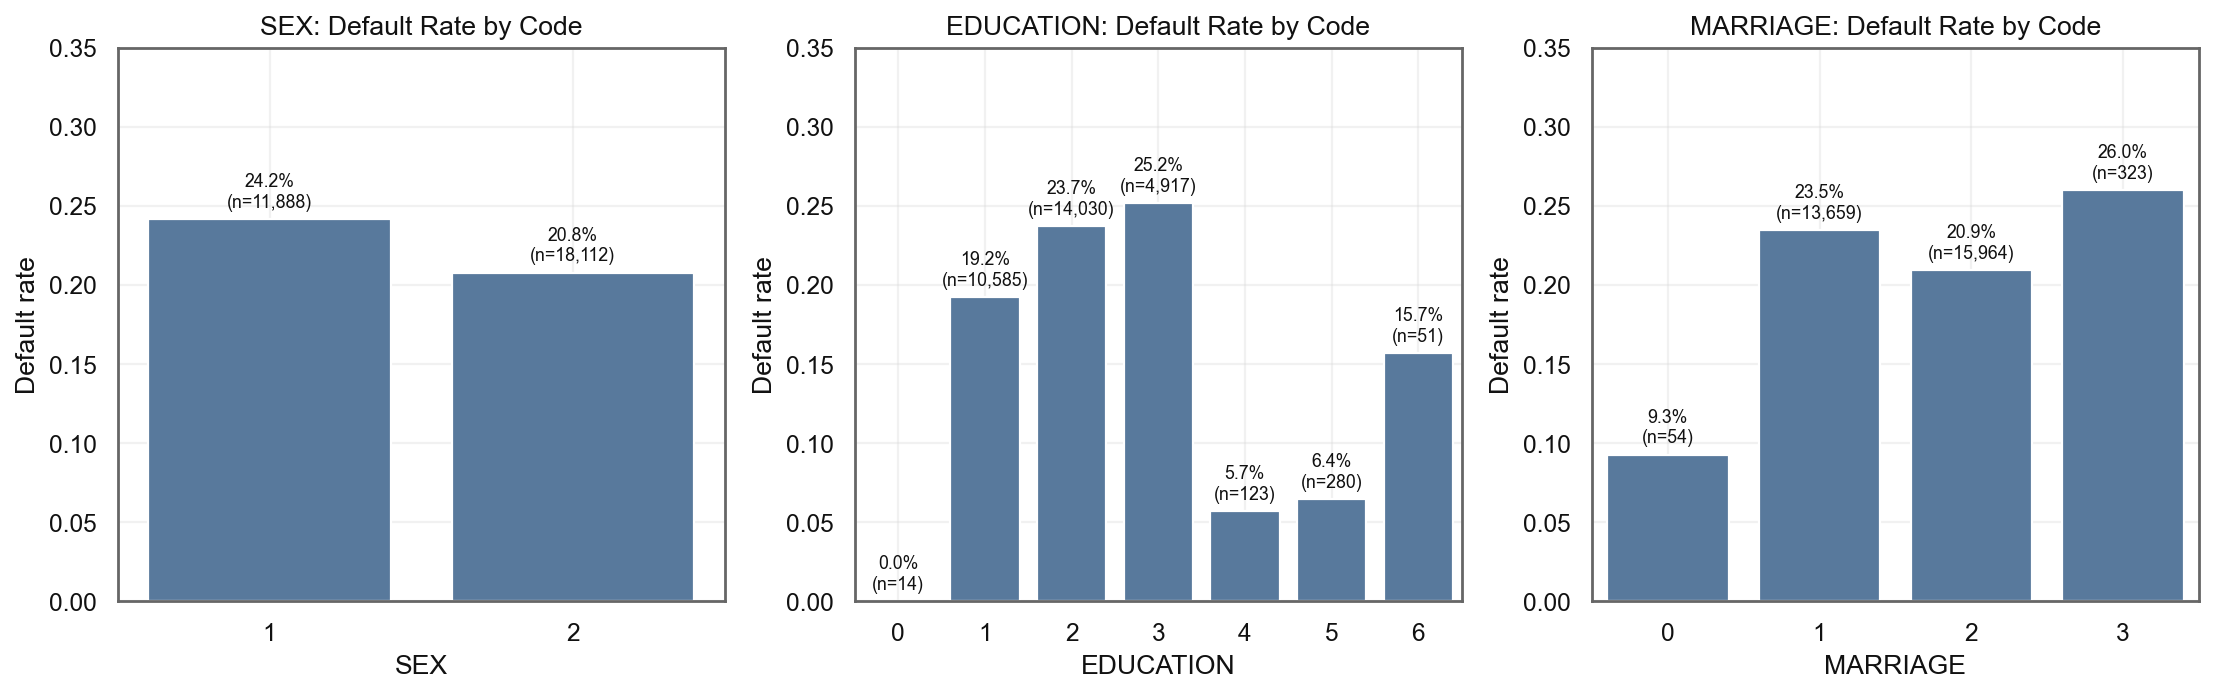

pay_status_default_rates_by_code.png


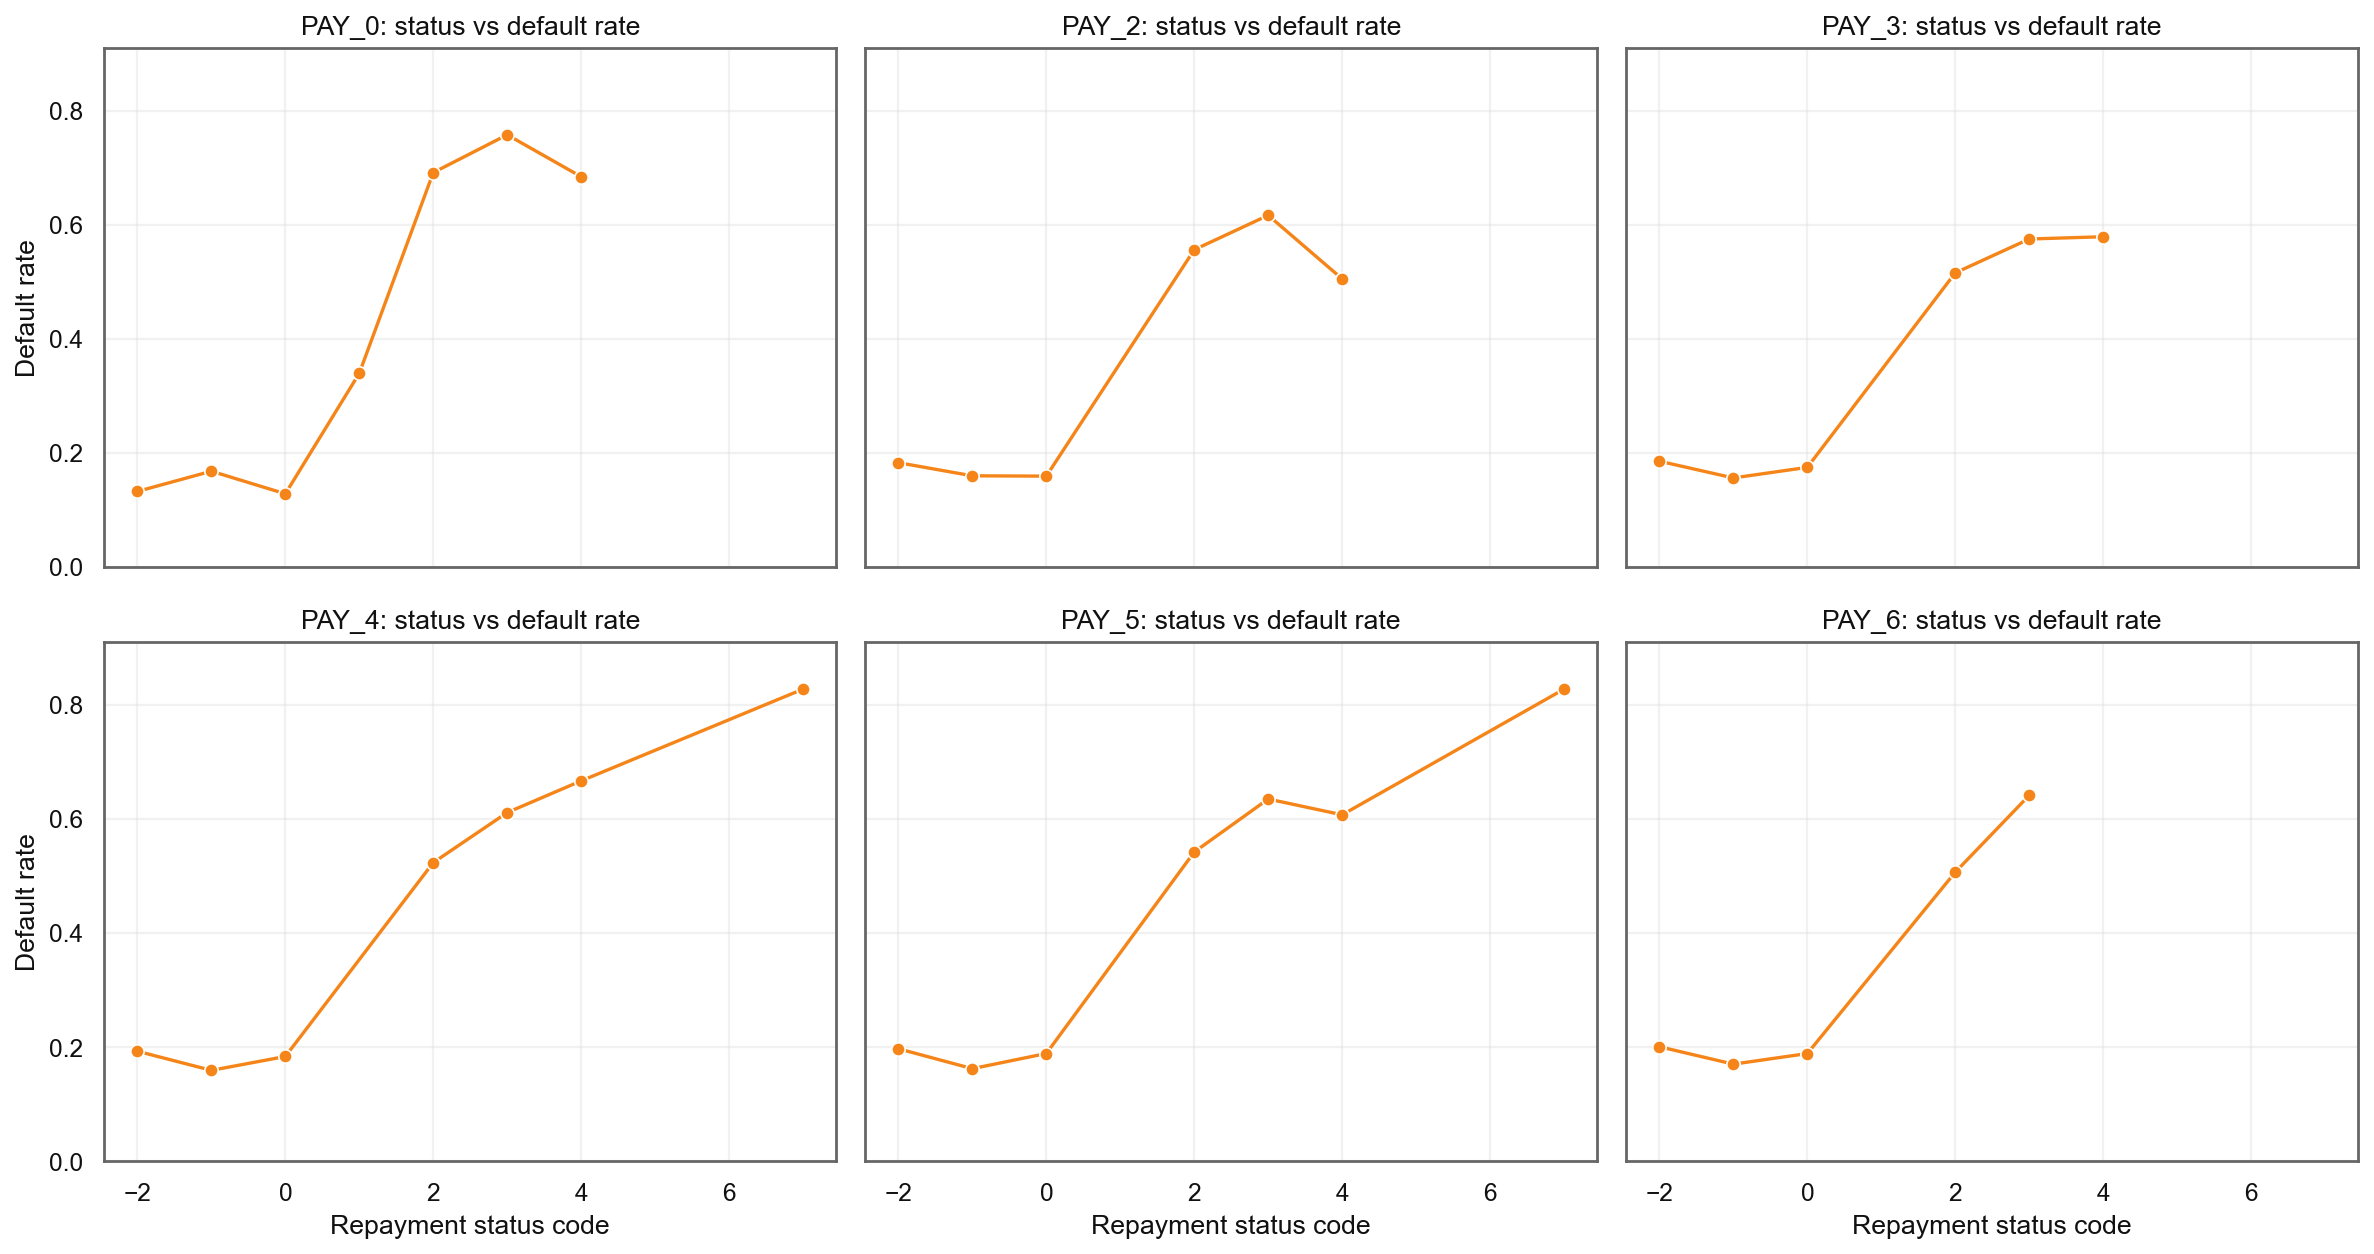

feature_distributions_by_target.png


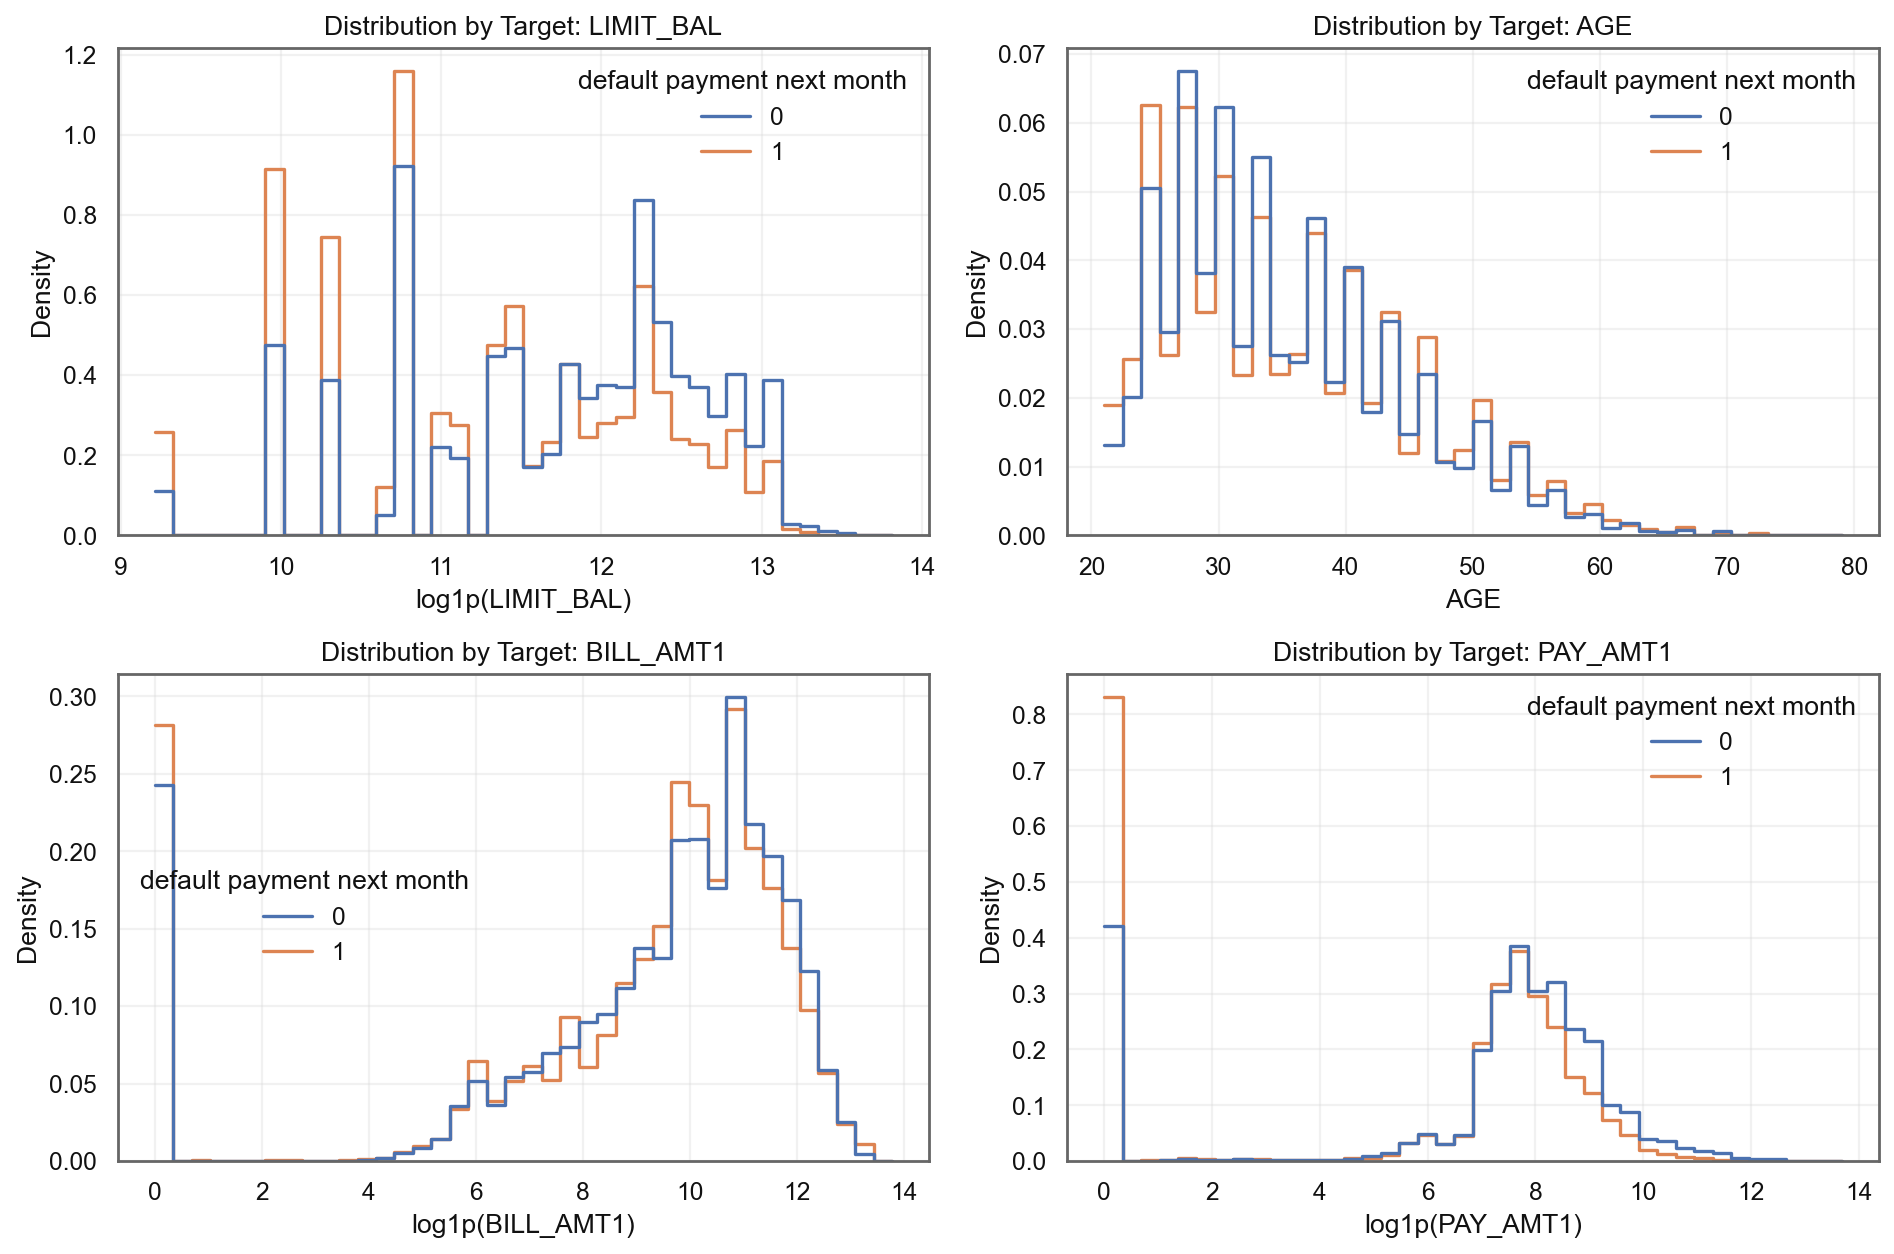

boxplots_by_target.png


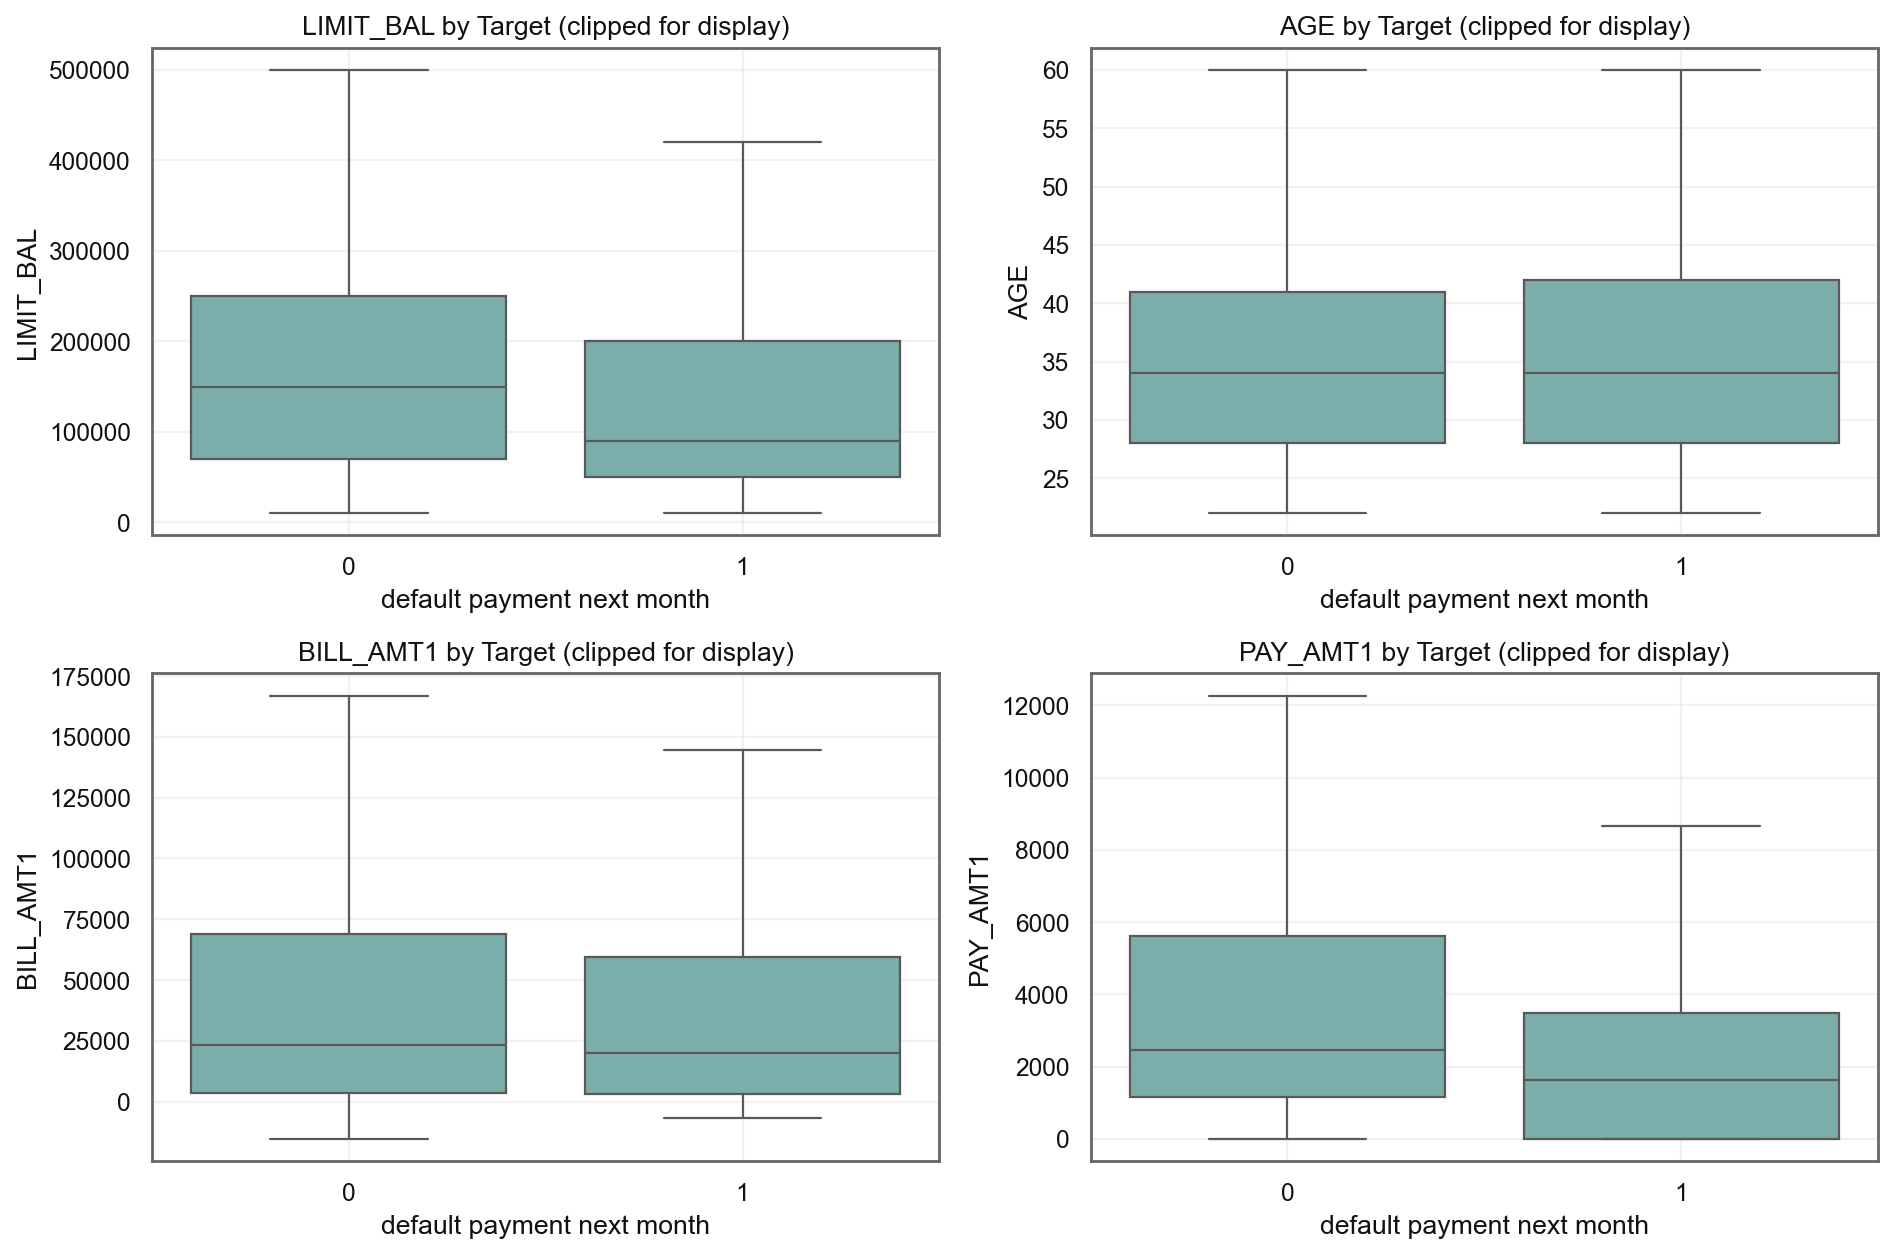

top_iqr_outlier_rates.png


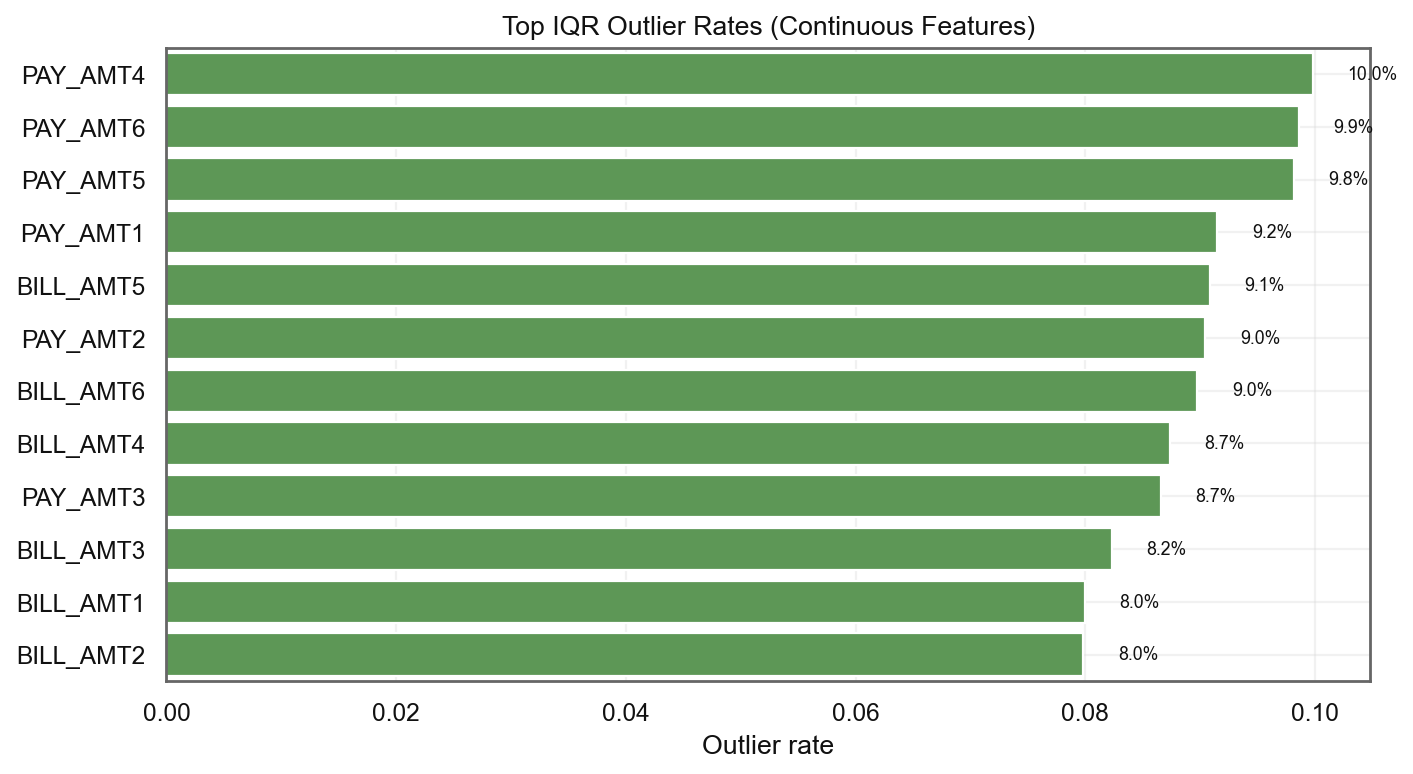

correlation_heatmap_top_features.png


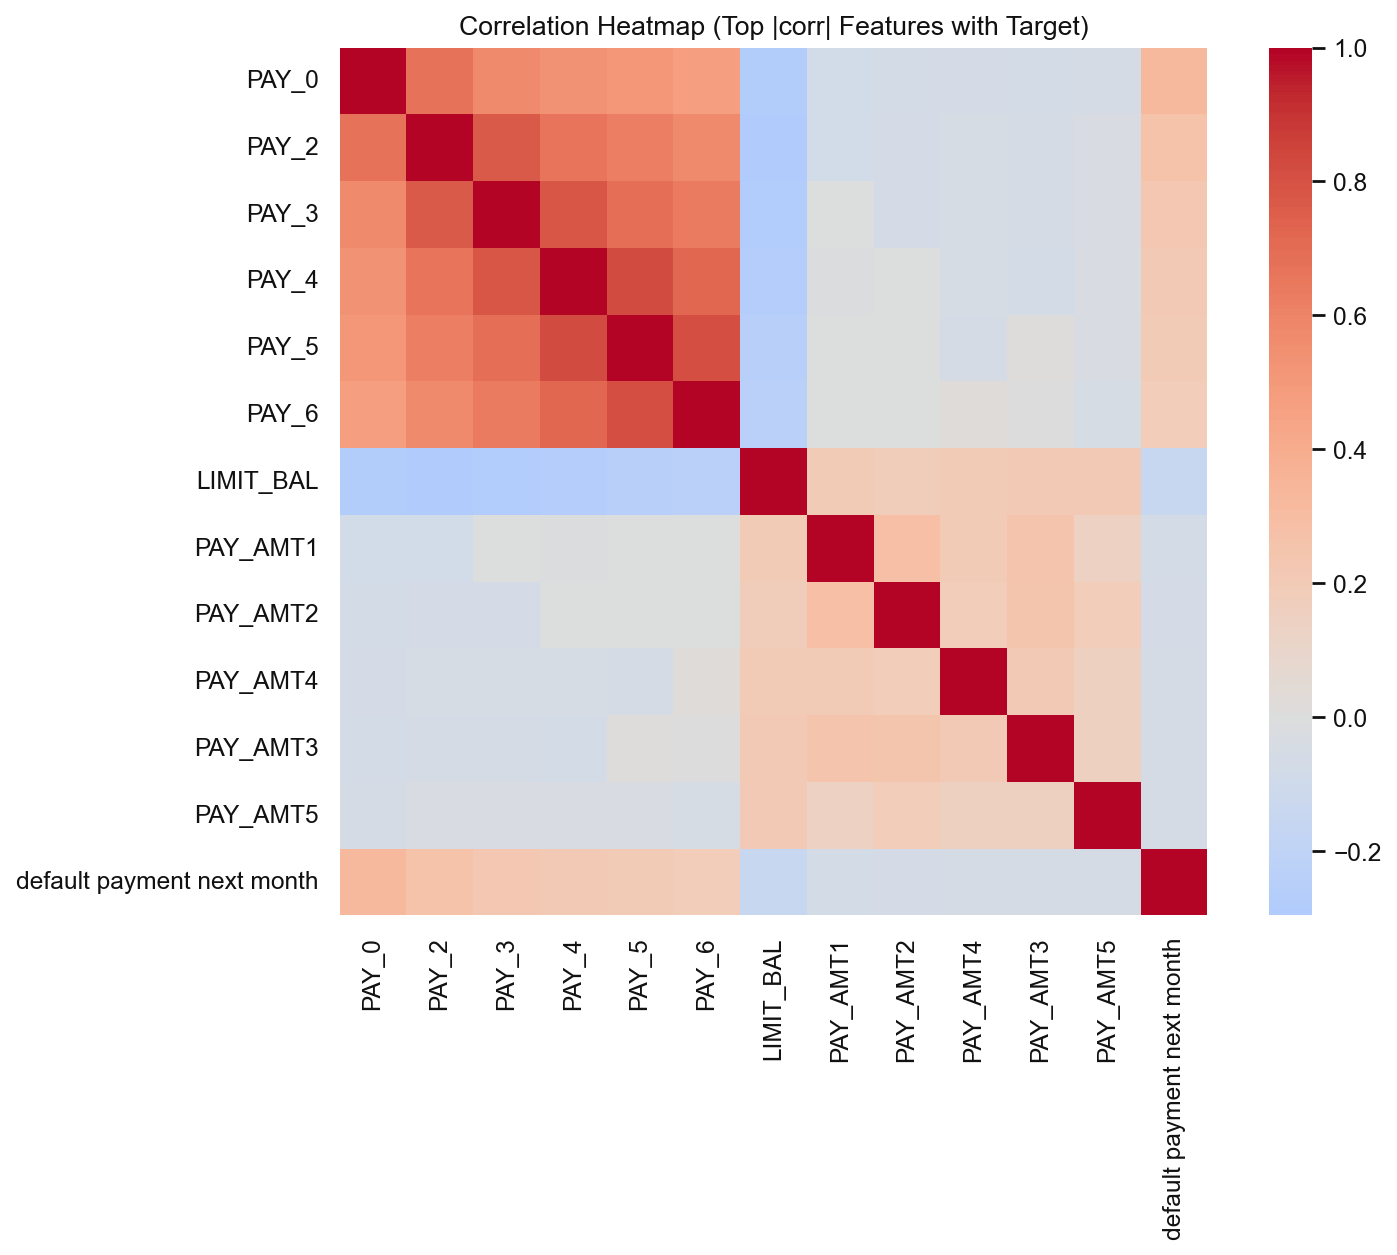

In [30]:
# View the saved EDA plots
for name in [
    'categorical_code_default_rates.png',
    'pay_status_default_rates_by_code.png',
    'feature_distributions_by_target.png',
    'boxplots_by_target.png',
    'top_iqr_outlier_rates.png',
    'correlation_heatmap_top_features.png',
]:
    print(name)
    display(Image(filename=str(EDA_FIG_DIR / name)))

### Step 2 Decision Summary

- `PAY_*` repayment-status features are strongest and non-linear in relation to default risk.
- Monetary features are right-skewed/zero-inflated; negative bill amounts appear plausible and were retained.
- Undocumented codes were observed in `EDUCATION` and `MARRIAGE` and kept for robust categorical handling.
- Decision: compare linear and non-linear models; treat code variables as categorical; exclude `ID` from model inputs later.

**Artifacts**: `outputs/metrics/step2_eda/`, `outputs/figures/step2_eda/`

## Step 3: Data Preparation and Preprocessing

### Step 3 Goal

- Build a reproducible split + preprocessing pipeline with stratified train/validation/test discipline.
- Exclude `ID` from modeling and apply transformations consistently across splits.
- Prevent preprocessing leakage by fitting transformations on training data only.
- Implementation script: `src/step3_preprocessing.py`.

In [31]:
from src.step3_preprocessing import run_step3_preprocessing

step3_artifacts = run_step3_preprocessing(df, OUTPUTS_DIR, random_state=RANDOM_STATE, test_size=0.20, val_size=0.20)
step3_artifacts

Step3Artifacts(split_summary={'random_state': 42, 'test_size': 0.2, 'val_size': 0.2, 'train_size': 0.6000000000000001, 'n_total': 30000, 'n_features_raw_model_input': 23, 'id_excluded_from_modeling': True, 'target_column': 'default payment next month', 'feature_columns_used': ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'], 'numeric_features': ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'], 'categorical_features': ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'], 'split_counts': {'train': 18000, 'validation': 6000, 'test': 6000}, 'class_distribution': {'overall': {'count_0': 23364, 'count_1': 6636, 'positive_rate': 0.2212

In [32]:
STEP3_METRICS_DIR = METRICS_DIR / 'step3_preprocessing'
STEP3_MODELS_DIR = MODELS_DIR / 'step3_preprocessing'

split_summary = json.loads((STEP3_METRICS_DIR / 'split_summary.json').read_text())
preproc_summary = json.loads((STEP3_METRICS_DIR / 'preprocessing_summary.json').read_text())

print('Split summary:')
print(json.dumps(split_summary, indent=2))

print('\nPreprocessing summary:')
print(json.dumps(preproc_summary, indent=2))

Split summary:
{
  "random_state": 42,
  "test_size": 0.2,
  "val_size": 0.2,
  "train_size": 0.6000000000000001,
  "n_total": 30000,
  "n_features_raw_model_input": 23,
  "id_excluded_from_modeling": true,
  "target_column": "default payment next month",
  "feature_columns_used": [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
  ],
  "numeric_features": [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
  ],
  "categorical_features": [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",

In [33]:
# Inspect split assignments and transformed feature names (sanity checks)
split_assignments = pd.read_csv(STEP3_METRICS_DIR / 'split_assignments.csv')
feature_names = (STEP3_METRICS_DIR / 'preprocessor_feature_names.txt').read_text().splitlines()
transformed_sample = pd.read_csv(STEP3_METRICS_DIR / 'transformed_train_sample.csv')

display(split_assignments.head())
display(split_assignments['split'].value_counts())
display(split_assignments.groupby('split')['target'].mean().rename('positive_rate'))

print(f'Number of transformed features: {len(feature_names)}')
print('First 20 transformed features:')
print(feature_names[:20])
print('ID present in transformed features?', any('ID' in f for f in feature_names))

display(transformed_sample.head())

,row_index,ID,target,split
0,0,1,1,train
1,1,2,1,test
2,2,3,0,train
3,3,4,0,train
4,4,5,0,train


split
train         18000
test           6000
validation     6000
Name: count, dtype: int64

split
test          0.221167
train         0.221222
validation    0.221167
Name: positive_rate, dtype: float64

Number of transformed features: 91
First 20 transformed features:
['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_1', 'SEX_2', 'EDUCATION_0', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3']
ID present in transformed features? False


,row_index,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,...,PAY_6_-2,PAY_6_-1,PAY_6_0,PAY_6_2,PAY_6_3,PAY_6_4,PAY_6_5,PAY_6_6,PAY_6_7,PAY_6_8
0,10574,-0.631579,1.307692,-0.048886,-0.005798,-0.349158,-0.366317,-0.372494,-0.355566,-0.024944,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11330,0.842105,-0.230769,4.164174,4.474193,4.877932,2.173897,2.292889,2.271413,2.595909,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7127,1.894737,0.461538,0.171830,1.271751,0.492020,0.590901,0.456011,0.782654,24.210277,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,25150,-0.368421,0.923077,0.761031,0.811660,0.900215,0.789735,0.238461,0.206886,0.124719,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6000,-0.473684,-0.076923,-0.139509,-0.195217,-0.228650,-0.235473,-0.259868,-0.241132,-0.024944,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Step 3 Method

- Stratified split: `60% train / 20% validation / 20% test`
- Exclude `ID` from model inputs (retain for traceability artifacts)
- Numeric pipeline: median imputation + robust scaling
- Categorical/code pipeline: most-frequent imputation + one-hot encoding (`handle_unknown='ignore'`)
- Fit transformations on training data only

### Step 3 Decision Summary

- Split discipline and leakage controls are validated.
- Transformed feature space expanded from `23` modelling inputs to `91` processed features.
- Decision: proceed to model comparison using this fixed preprocessing setup.

**Artifacts**: `outputs/metrics/step3_preprocessing/`, `outputs/models/step3_preprocessing/preprocessor.joblib`

## Step 4: Model Development and Comparison

### Step 4 Goal

- Train and compare candidate models under identical preprocessing and split discipline.
- Use validation data for model comparison with `PR-AUC` as the primary ranking metric.
- Report complementary metrics without using test data at this stage.
- Implementation script: `src/step4_model_comparison.py`.

In [34]:
from IPython.display import Image, display
from src.step4_model_comparison import run_step4_model_comparison

step4_artifacts = run_step4_model_comparison(df, OUTPUTS_DIR, random_state=RANDOM_STATE)
step4_artifacts

Step4Artifacts(comparison_table_path='/Users/cindylow/Documents/New project 5/outputs/metrics/step4_model_comparison/validation_model_comparison.csv', metrics_dir='/Users/cindylow/Documents/New project 5/outputs/metrics/step4_model_comparison', figure_dir='/Users/cindylow/Documents/New project 5/outputs/figures/step4_model_comparison', models_dir='/Users/cindylow/Documents/New project 5/outputs/models/step4_model_comparison', best_model_by_pr_auc='hist_gradient_boosting', validation_metrics=[{'model_name': 'hist_gradient_boosting', 'pr_auc': 0.545628915381108, 'roc_auc': 0.7825279697652228, 'balanced_accuracy': 0.7077990237492846, 'f1': 0.530440414507772, 'recall': 0.6171816126601356, 'precision': 0.46507666098807493, 'accuracy': 0.7583333333333333, 'log_loss': 0.5384471235923787, 'brier_score': 0.17779483993437484, 'fit_seconds': 0.5975607079999463}, {'model_name': 'mlp_neural_network', 'pr_auc': 0.5368526186270695, 'roc_auc': 0.7693317009271463, 'balanced_accuracy': 0.655658836997673

In [35]:
STEP4_METRICS_DIR = METRICS_DIR / 'step4_model_comparison'
STEP4_FIG_DIR = FIGURES_DIR / 'step4_model_comparison'
STEP4_MODELS_DIR = MODELS_DIR / 'step4_model_comparison'

comparison_df = pd.read_csv(STEP4_METRICS_DIR / 'validation_model_comparison.csv')
ranking_df = pd.read_csv(STEP4_METRICS_DIR / 'validation_model_ranking_table.csv')
comparison_summary = json.loads((STEP4_METRICS_DIR / 'model_comparison_summary.json').read_text())

display(ranking_df.sort_values('pr_auc', ascending=False))
print(json.dumps(comparison_summary, indent=2))

,model_name,pr_auc,roc_auc,balanced_accuracy,f1,recall,precision,accuracy,log_loss,brier_score,fit_seconds
0,hist_gradient_boosting,0.545629,0.782528,0.707799,0.530440,0.617182,0.465077,0.758333,0.538447,0.177795,0.597561
1,mlp_neural_network,0.536853,0.769332,0.655659,0.470069,0.360965,0.673699,0.820000,0.437850,0.136243,0.313717
2,logistic_regression,0.534875,0.761773,0.544321,0.382519,0.972871,0.238060,0.305333,0.987316,0.362973,0.131072


{
  "random_state": 42,
  "evaluation_split": "validation",
  "n_train": 18000,
  "n_validation": 6000,
  "validation_positive_rate": 0.22116666666666668,
  "primary_ranking_metric": "pr_auc",
  "best_model_by_pr_auc": "hist_gradient_boosting",
  "models_compared": [
    "hist_gradient_boosting",
    "mlp_neural_network",
    "logistic_regression"
  ]
}


In [36]:
# Optional: inspect train-vs-validation deltas for overfitting signals
cols = ['model_name', 'train_pr_auc', 'pr_auc', 'train_roc_auc', 'roc_auc', 'train_f1', 'f1', 'fit_seconds']
display(comparison_df[cols].sort_values('pr_auc', ascending=False))

,model_name,train_pr_auc,pr_auc,train_roc_auc,roc_auc,train_f1,f1,fit_seconds
0,hist_gradient_boosting,0.612194,0.545629,0.833897,0.782528,0.581818,0.530440,0.597561
1,mlp_neural_network,0.573665,0.536853,0.791824,0.769332,0.487097,0.470069,0.313717
2,logistic_regression,0.549923,0.534875,0.777461,0.761773,0.384274,0.382519,0.131072


validation_metric_comparison_bar.png


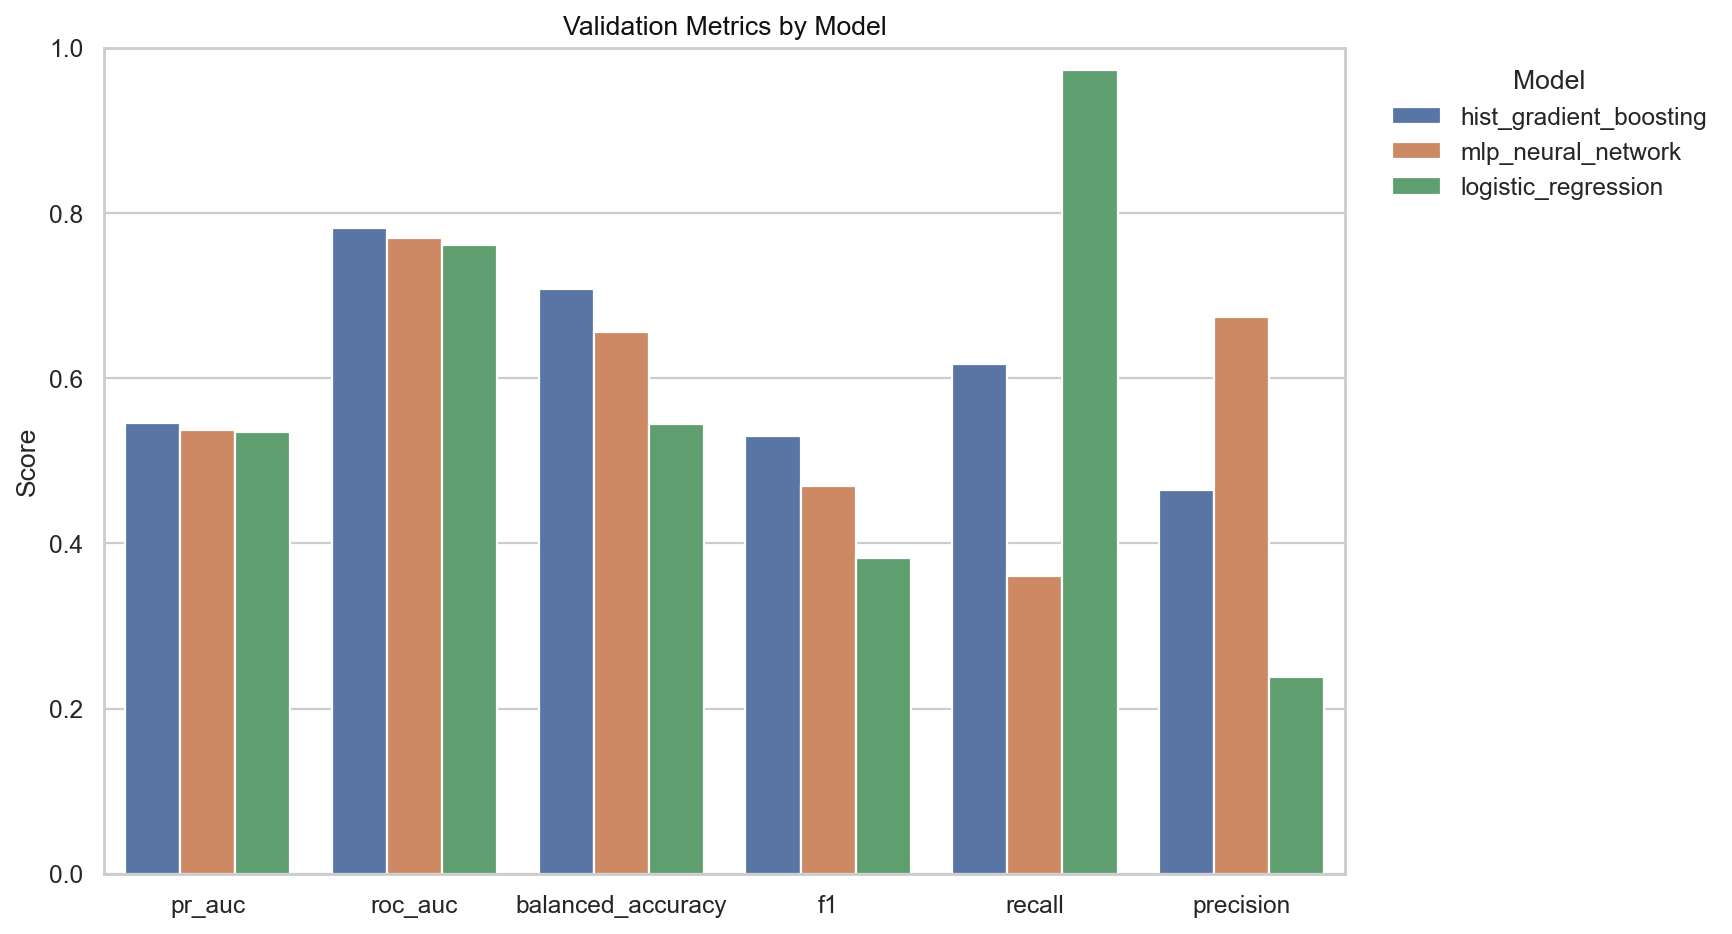

validation_roc_curves.png


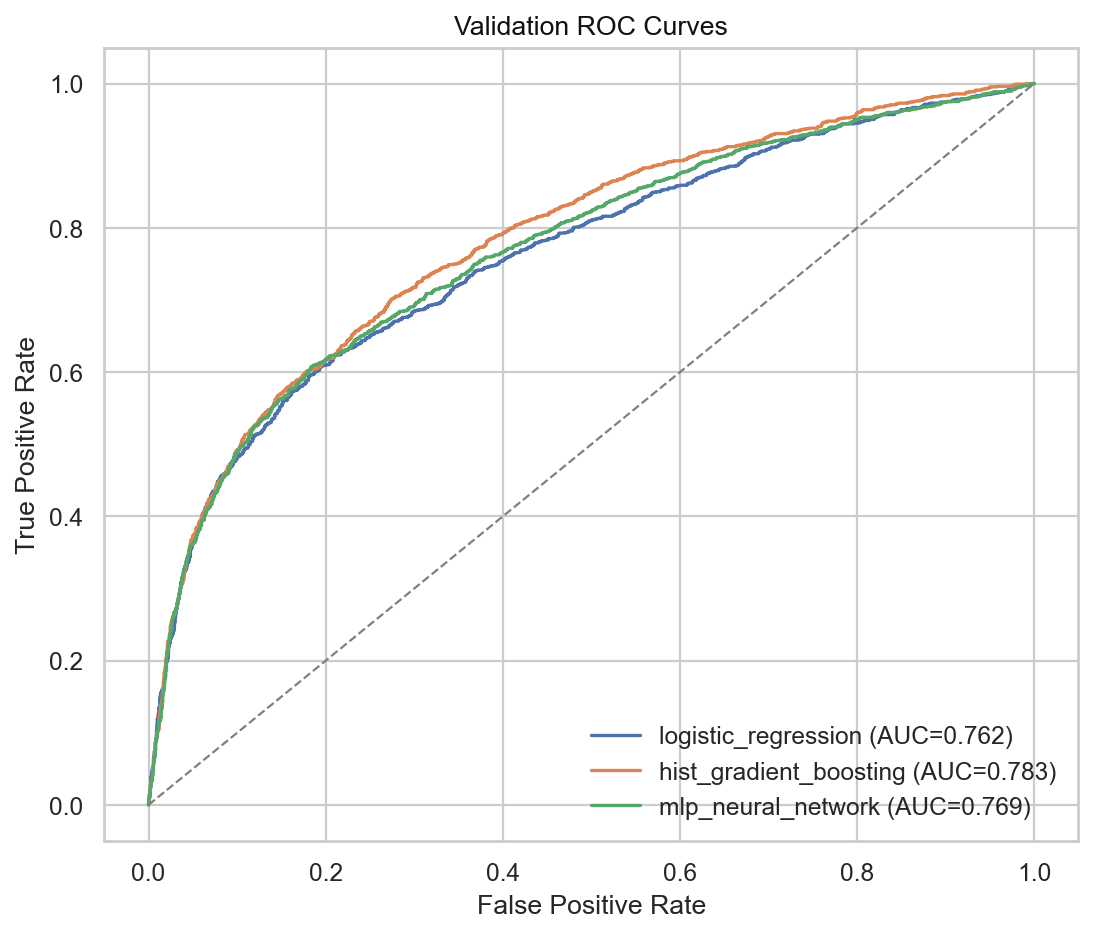

validation_pr_curves.png


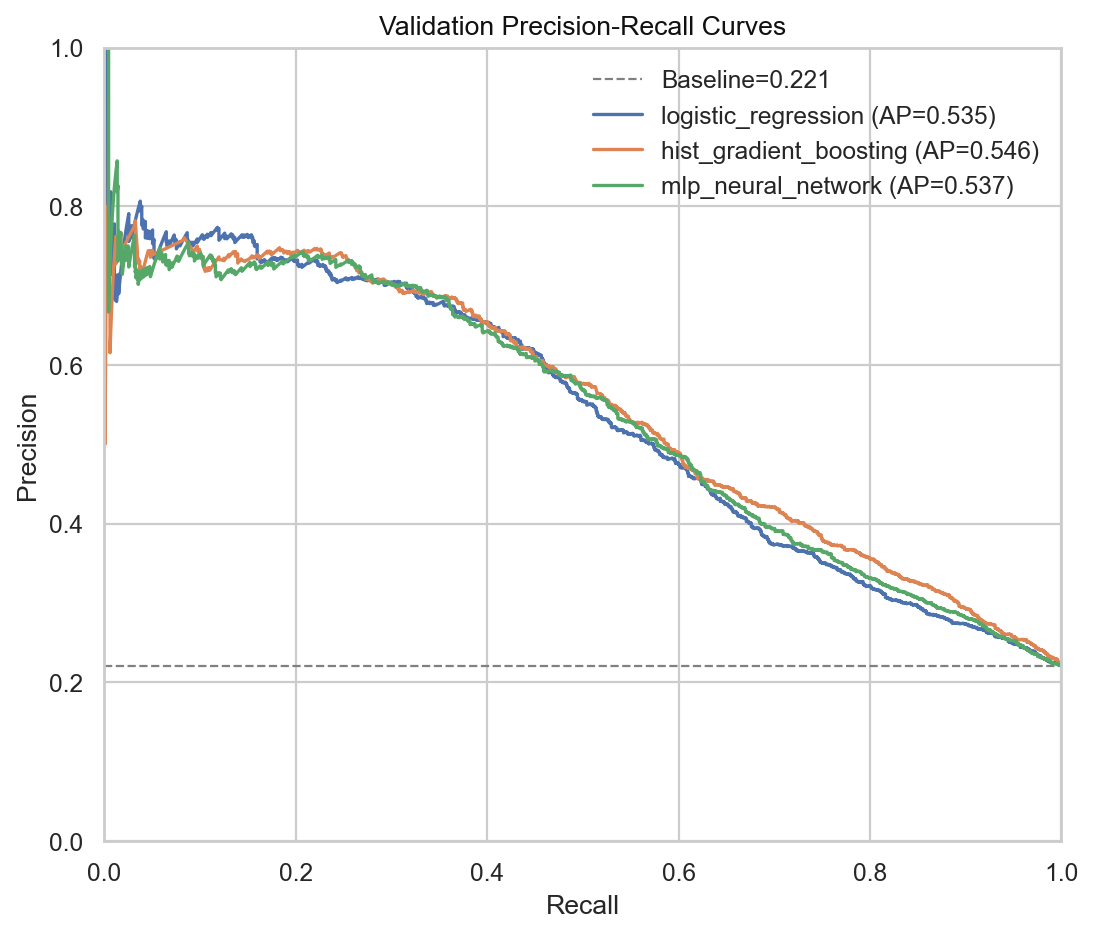

validation_confusion_matrices.png


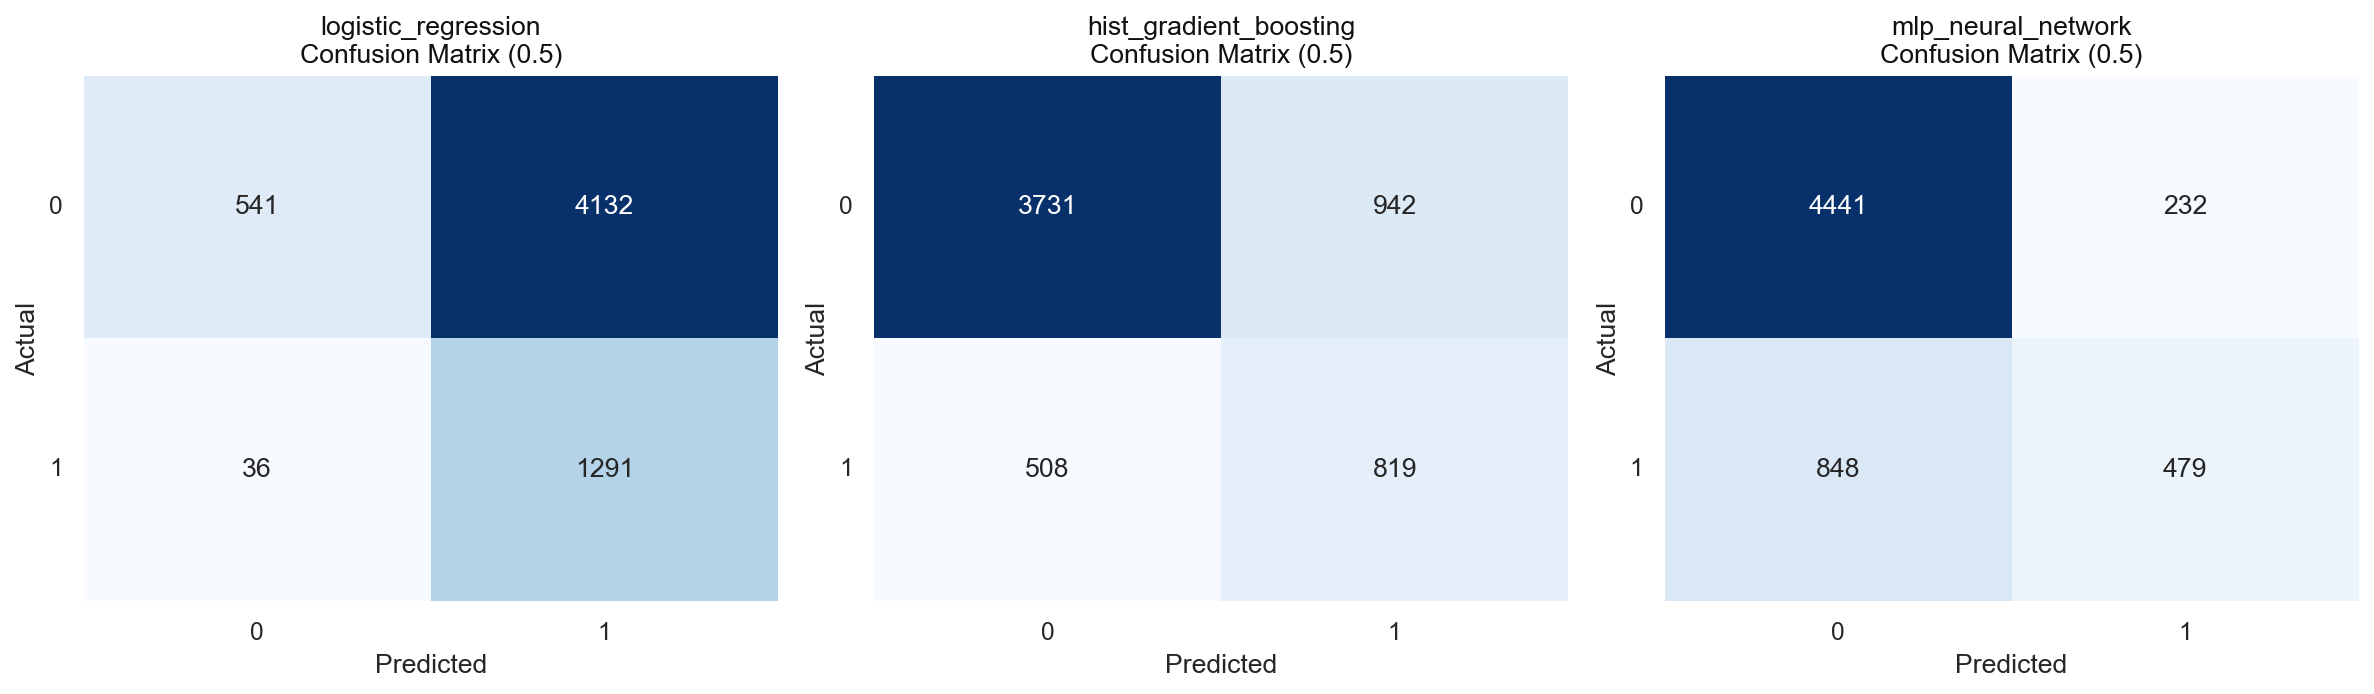

In [37]:
# View saved comparison plots
for name in [
    'validation_metric_comparison_bar.png',
    'validation_roc_curves.png',
    'validation_pr_curves.png',
    'validation_confusion_matrices.png',
]:
    print(name)
    display(Image(filename=str(STEP4_FIG_DIR / name)))

### Step 4 Decision Summary

- Compared `LogisticRegression`, `HistGradientBoostingClassifier`, and `MLPClassifier`.
- `HistGradientBoosting` ranked best on validation PR-AUC; `MLP` remained competitive.
- Decision: shortlist `HistGradientBoosting` + `MLP` for tuning; keep logistic regression as baseline reference.

**Artifacts**: `outputs/metrics/step4_model_comparison/`, `outputs/figures/step4_model_comparison/`, `outputs/models/step4_model_comparison/`

## Step 5: Model Tuning and Robust Validation

### Step 5 Goal

- Tune shortlisted models using validation-only evidence.
- Select operating thresholds on validation data after ranking-based model selection.
- Run additional diagnostics (calibration, error patterns, training behaviour) without touching test data.
- Implementation scripts: `src/step5_tuning.py` and `src/step5_diagnostics.py`.

In [38]:
from src.step5_tuning import run_step5_tuning

step5_artifacts = run_step5_tuning(df, OUTPUTS_DIR, random_state=RANDOM_STATE)
step5_artifacts

Step5Artifacts(metrics_dir='/Users/cindylow/Documents/New project 5/outputs/metrics/step5_tuning', figures_dir='/Users/cindylow/Documents/New project 5/outputs/figures/step5_tuning', models_dir='/Users/cindylow/Documents/New project 5/outputs/models/step5_tuning', best_configs={'hist_gradient_boosting': {'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 80, 'l2_regularization': 0.1}, 'mlp_neural_network': {'hidden_layer_sizes': (128,), 'alpha': 0.0001, 'learning_rate_init': 0.001, 'batch_size': 256, 'max_iter': 250}}, selected_thresholds={'hist_gradient_boosting': {'threshold_selection_rule': 'maximize_f1_on_validation', 'selected_threshold_for_f1': 0.57, 'best_f1_metrics': {'threshold': 0.57, 'accuracy': 0.7936666666666666, 'balanced_accuracy': 0.7102481168172401, 'precision': 0.5318084345961401, 'recall': 0.560663149962321, 'f1': 0.5458547322083639, 'roc_auc': 0.7839340978356804, 'pr_auc': 0.547593412587478, 'log_loss': 0.5380414648190199, 'brier_score

In [39]:
STEP5_METRICS_DIR = METRICS_DIR / 'step5_tuning'
STEP5_FIG_DIR = FIGURES_DIR / 'step5_tuning'
STEP5_MODELS_DIR = MODELS_DIR / 'step5_tuning'

search_results = pd.read_csv(STEP5_METRICS_DIR / 'hyperparameter_search_results.csv')
tuned_ranking = pd.read_csv(STEP5_METRICS_DIR / 'tuned_shortlisted_model_ranking.csv')
threshold_compare = pd.read_csv(STEP5_METRICS_DIR / 'threshold_tuning_comparison_metrics.csv')
step5_summary = json.loads((STEP5_METRICS_DIR / 'step5_tuning_summary.json').read_text())

display(tuned_ranking.sort_values('validation_pr_auc', ascending=False))
display(search_results.sort_values(['model_name', 'validation_pr_auc'], ascending=[True, False]))
display(threshold_compare[['model_name', 'metric_set', 'threshold', 'pr_auc', 'roc_auc', 'balanced_accuracy', 'f1', 'recall', 'precision']])
print(json.dumps(step5_summary, indent=2))

,model_name,best_params_json,selection_metric,validation_pr_auc,validation_roc_auc,validation_default_threshold,validation_selected_threshold_f1,validation_default_f1,validation_tuned_f1,validation_default_balanced_accuracy,validation_tuned_balanced_accuracy
0,hist_gradient_boosting,"{""l2_regularization"": 0.1, ""learning_rate"": 0....",validation_pr_auc,0.547593,0.783934,0.5,0.57,0.533852,0.545855,0.710325,0.710248
1,mlp_neural_network,"{""alpha"": 0.0001, ""batch_size"": 256, ""hidden_l...",validation_pr_auc,0.539286,0.771008,0.5,0.25,0.445352,0.540183,0.643416,0.706485


,model_name,config_idx,fit_seconds,supports_sample_weight,used_sample_weight,params_json,param_learning_rate,param_max_iter,param_max_leaf_nodes,param_min_samples_leaf,...,validation_f1,validation_roc_auc,validation_pr_auc,validation_log_loss,validation_brier_score,validation_positive_prediction_rate,param_hidden_layer_sizes,param_alpha,param_learning_rate_init,param_batch_size
0,hist_gradient_boosting,5,0.349950,True,True,"{""l2_regularization"": 0.1, ""learning_rate"": 0....",0.05,300,31.0,80.0,...,0.533852,0.783934,0.547593,0.538041,0.177717,0.293333,NaN,NaN,NaN,NaN
1,hist_gradient_boosting,6,0.856145,True,True,"{""l2_regularization"": 0.1, ""learning_rate"": 0....",0.03,500,63.0,40.0,...,0.537284,0.782062,0.545659,0.530377,0.174610,0.290667,NaN,NaN,NaN,NaN
2,hist_gradient_boosting,2,0.434972,True,True,"{""l2_regularization"": 0.0, ""learning_rate"": 0....",0.05,300,31.0,40.0,...,0.530440,0.782528,0.545629,0.538447,0.177795,0.293500,NaN,NaN,NaN,NaN
3,hist_gradient_boosting,1,0.646702,True,True,"{""l2_regularization"": 0.0, ""learning_rate"": 0....",0.03,400,31.0,40.0,...,0.535576,0.783363,0.545573,0.538892,0.177919,0.294167,NaN,NaN,NaN,NaN
4,hist_gradient_boosting,3,0.537126,True,True,"{""l2_regularization"": 0.0, ""learning_rate"": 0....",0.05,400,63.0,20.0,...,0.535913,0.779031,0.544762,0.530029,0.174462,0.287000,NaN,NaN,NaN,NaN
5,hist_gradient_boosting,4,0.391495,True,True,"{""l2_regularization"": 0.0, ""learning_rate"": 0....",0.08,250,31.0,20.0,...,0.533724,0.780334,0.544087,0.536496,0.176858,0.290333,NaN,NaN,NaN,NaN
6,mlp_neural_network,3,0.304530,False,False,"{""alpha"": 0.0001, ""batch_size"": 256, ""hidden_l...",NaN,250,NaN,NaN,...,0.445352,0.771008,0.539286,0.435742,0.136093,0.105167,"(128,)",0.0001,0.0010,256.0
7,mlp_neural_network,1,0.310443,False,False,"{""alpha"": 0.0001, ""batch_size"": 256, ""hidden_l...",NaN,250,NaN,NaN,...,0.470069,0.769332,0.536853,0.437850,0.136243,0.118500,"(64, 32)",0.0001,0.0010,256.0
8,mlp_neural_network,2,0.532845,False,False,"{""alpha"": 0.0001, ""batch_size"": 256, ""hidden_l...",NaN,250,NaN,NaN,...,0.456105,0.769169,0.536670,0.437488,0.136226,0.109167,"(128, 64)",0.0001,0.0010,256.0
9,mlp_neural_network,4,0.296282,False,False,"{""alpha"": 0.001, ""batch_size"": 256, ""hidden_la...",NaN,250,NaN,NaN,...,0.474197,0.768770,0.534109,0.437339,0.136410,0.121167,"(64, 32)",0.0010,0.0010,256.0


,model_name,metric_set,threshold,pr_auc,roc_auc,balanced_accuracy,f1,recall,precision
0,hist_gradient_boosting,default_0.5,0.50,0.547593,0.783934,0.710325,0.533852,0.620950,0.468182
1,hist_gradient_boosting,tuned_threshold_f1,0.57,0.547593,0.783934,0.710248,0.545855,0.560663,0.531808
2,mlp_neural_network,default_0.5,0.50,0.539286,0.771008,0.643416,0.445352,0.328561,0.690967
3,mlp_neural_network,tuned_threshold_f1,0.25,0.539286,0.771008,0.706485,0.540183,0.554635,0.526466


{
  "random_state": 42,
  "tuning_split": "validation",
  "shortlisted_models": [
    "hist_gradient_boosting",
    "mlp_neural_network"
  ],
  "hyperparameter_selection_metric": "validation_pr_auc",
  "threshold_selection_metric": "validation_f1",
  "best_configs": {
    "hist_gradient_boosting": {
      "learning_rate": 0.05,
      "max_iter": 300,
      "max_leaf_nodes": 31,
      "min_samples_leaf": 80,
      "l2_regularization": 0.1
    },
    "mlp_neural_network": {
      "hidden_layer_sizes": [
        128
      ],
      "alpha": 0.0001,
      "learning_rate_init": 0.001,
      "batch_size": 256,
      "max_iter": 250
    }
  },
  "selected_thresholds": {
    "hist_gradient_boosting": {
      "threshold_selection_rule": "maximize_f1_on_validation",
      "selected_threshold_for_f1": 0.57,
      "best_f1_metrics": {
        "threshold": 0.57,
        "accuracy": 0.7936666666666666,
        "balanced_accuracy": 0.7102481168172401,
        "precision": 0.5318084345961401,
        "

hyperparameter_search_pr_auc.png


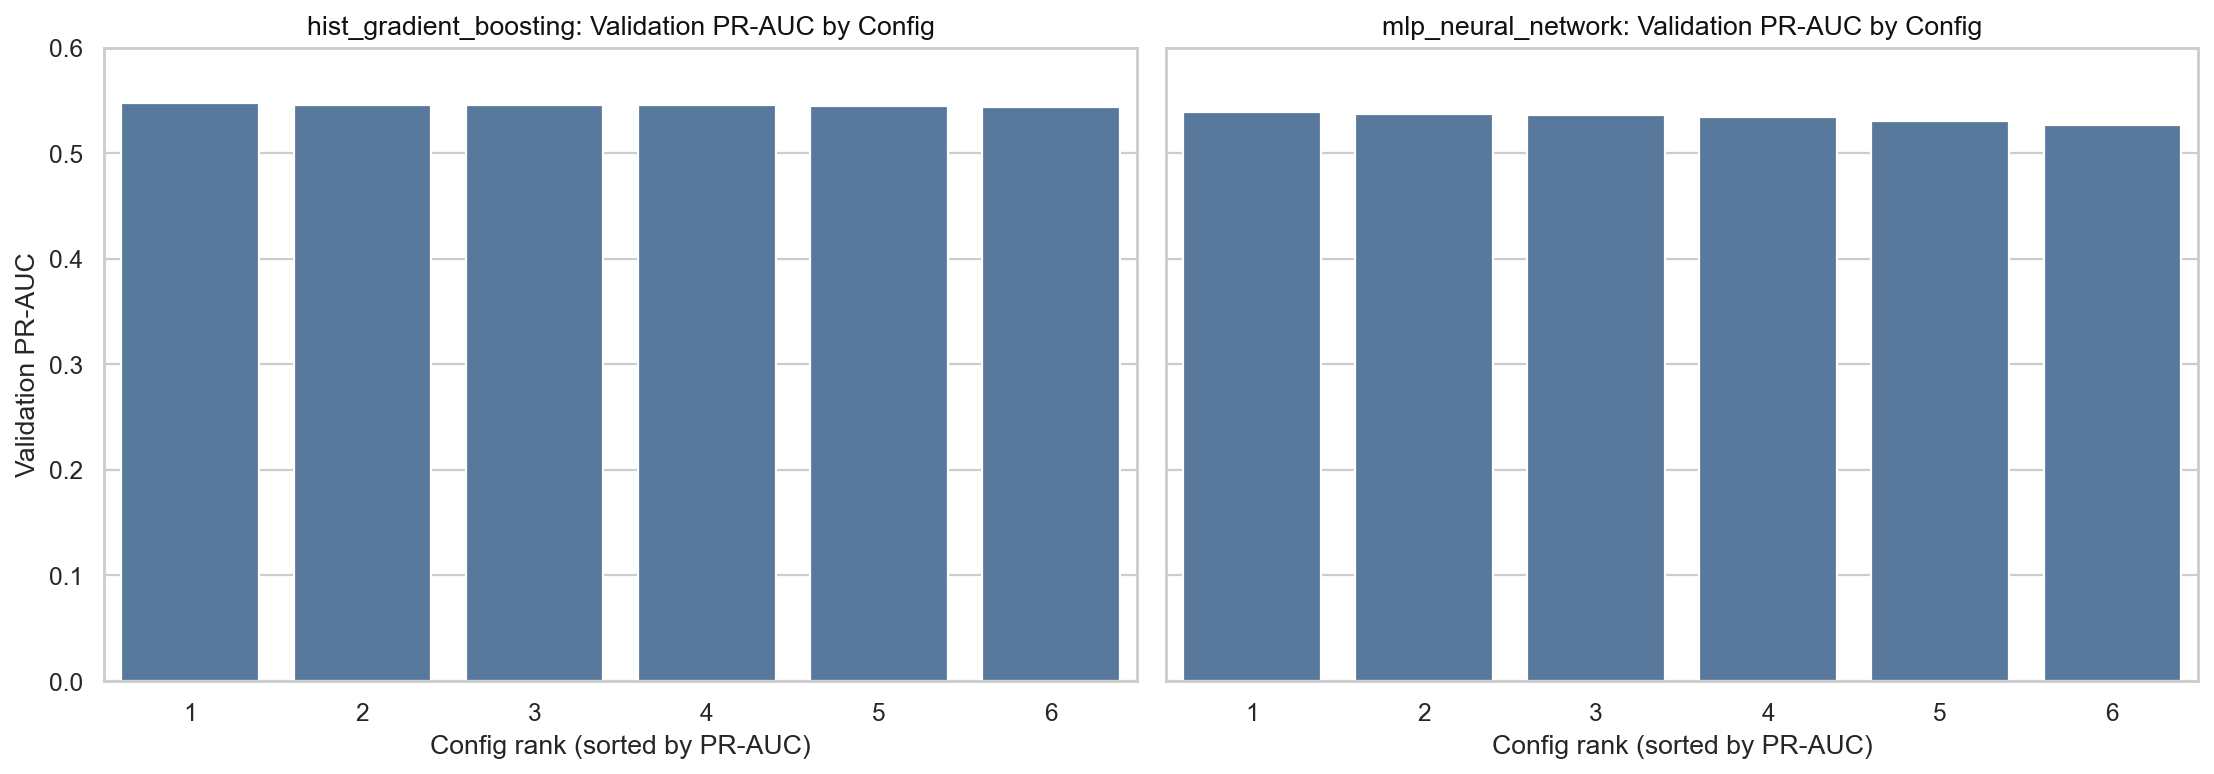

threshold_tuning_hist_gradient_boosting.png


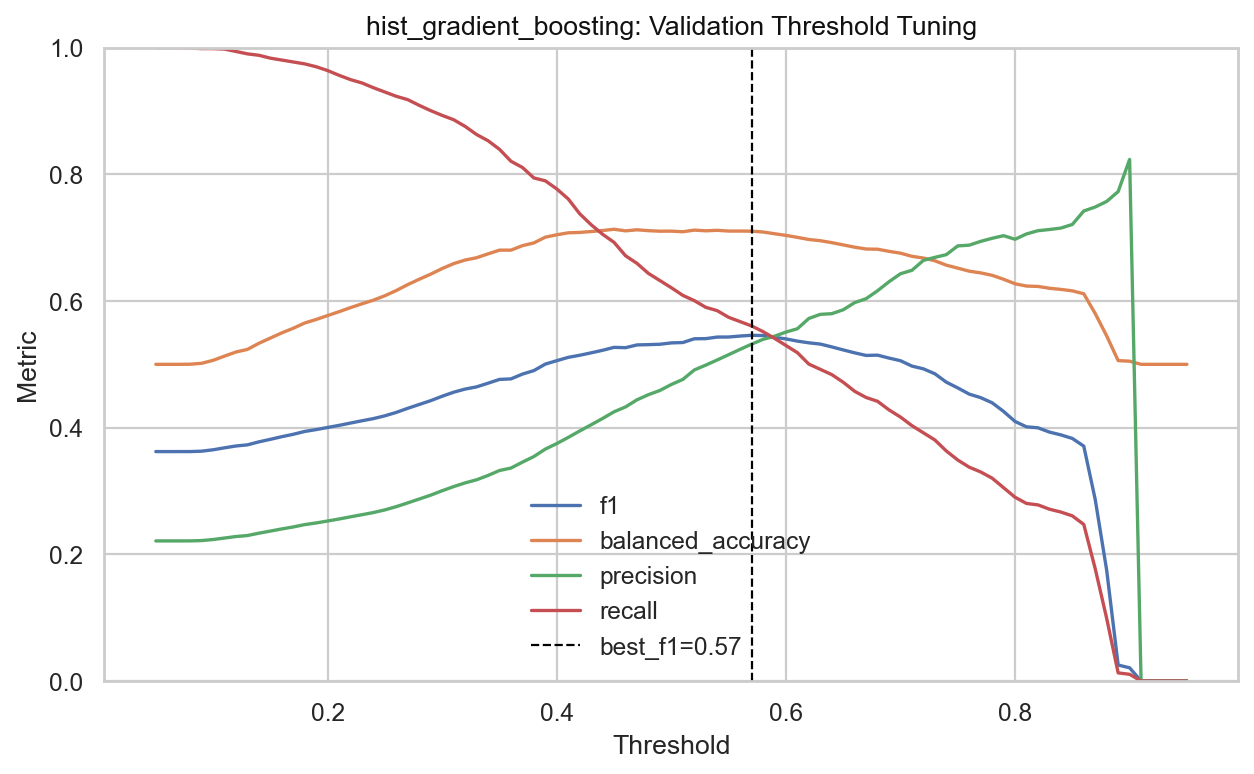

threshold_tuning_mlp_neural_network.png


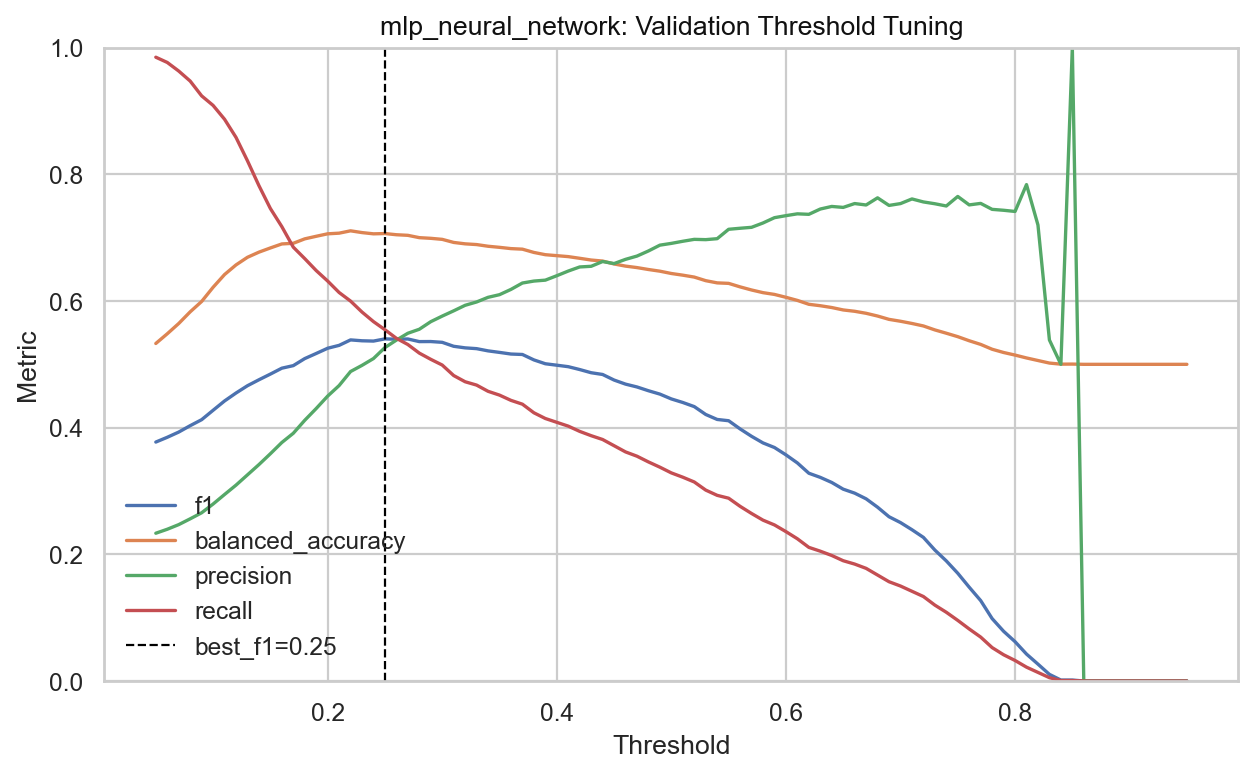

tuned_vs_default_threshold_metrics.png


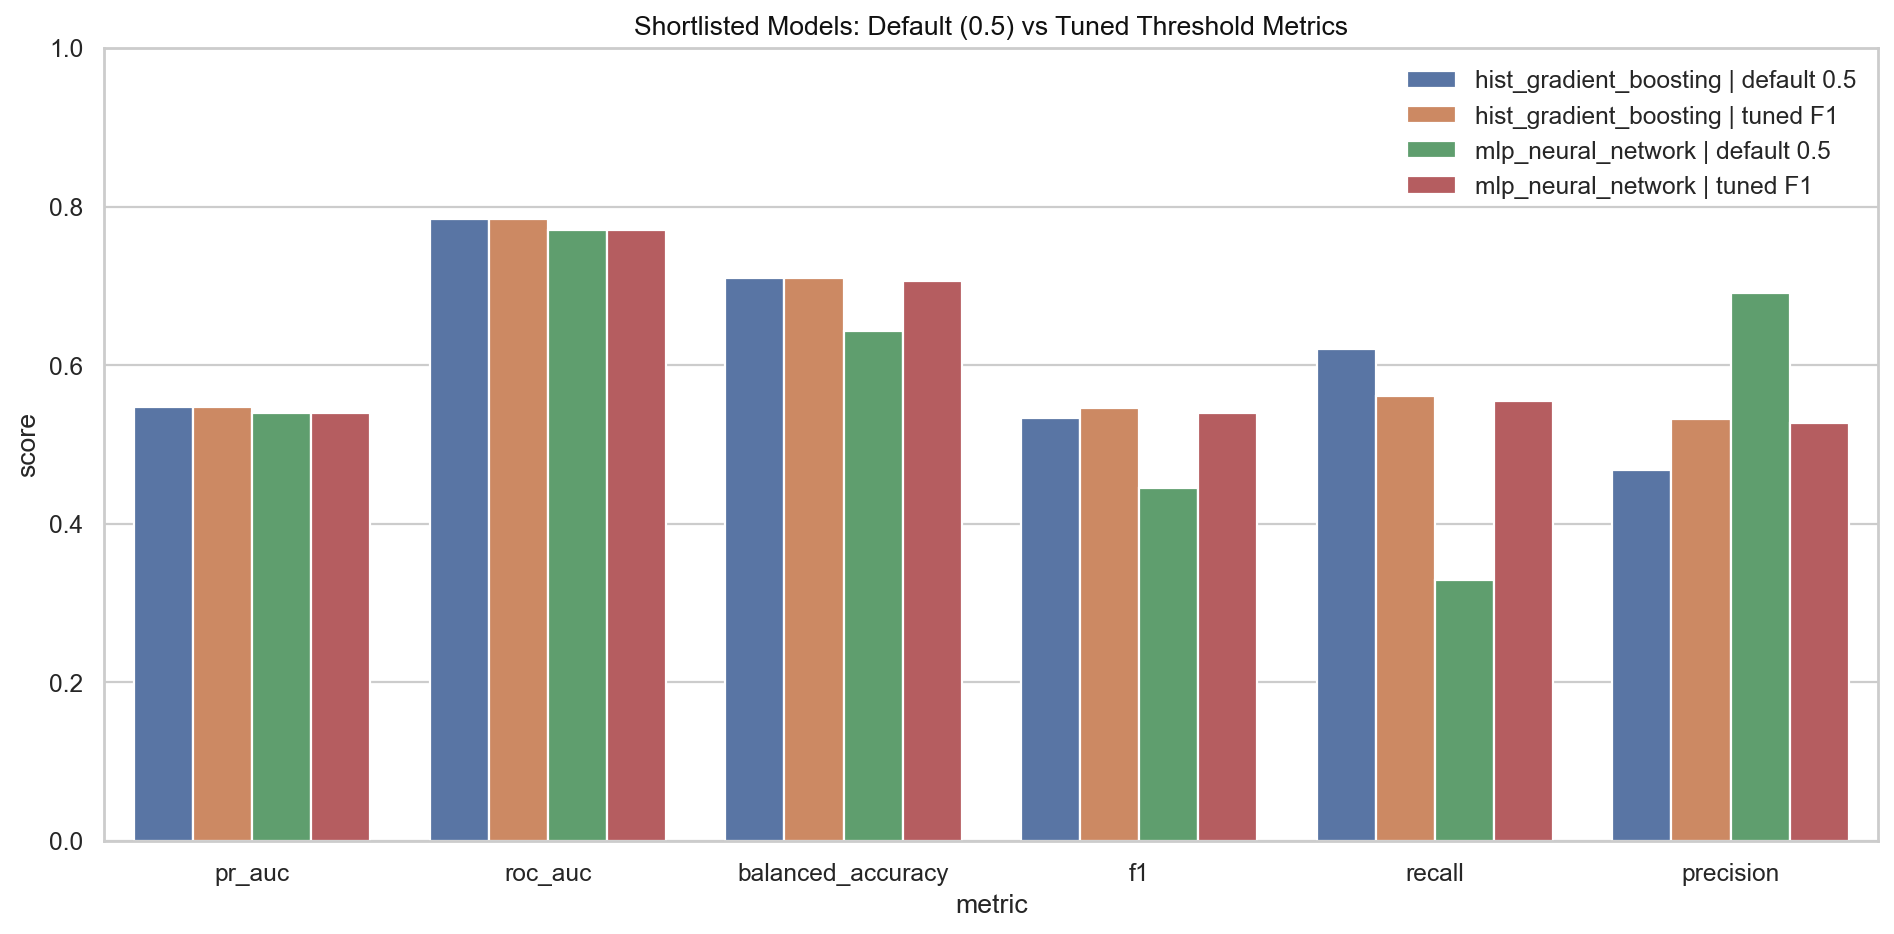

confusion_default_vs_tuned_hist_gradient_boosting.png


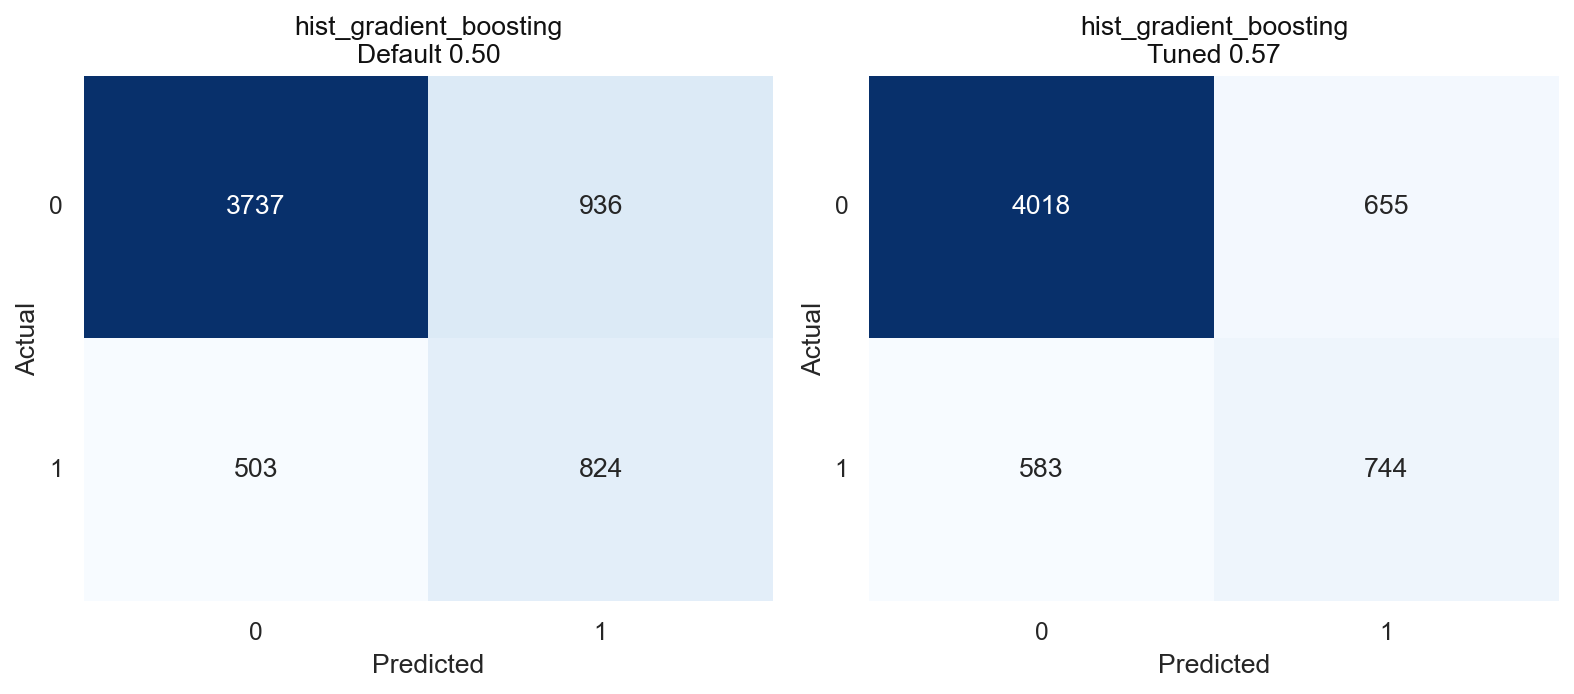

confusion_default_vs_tuned_mlp_neural_network.png


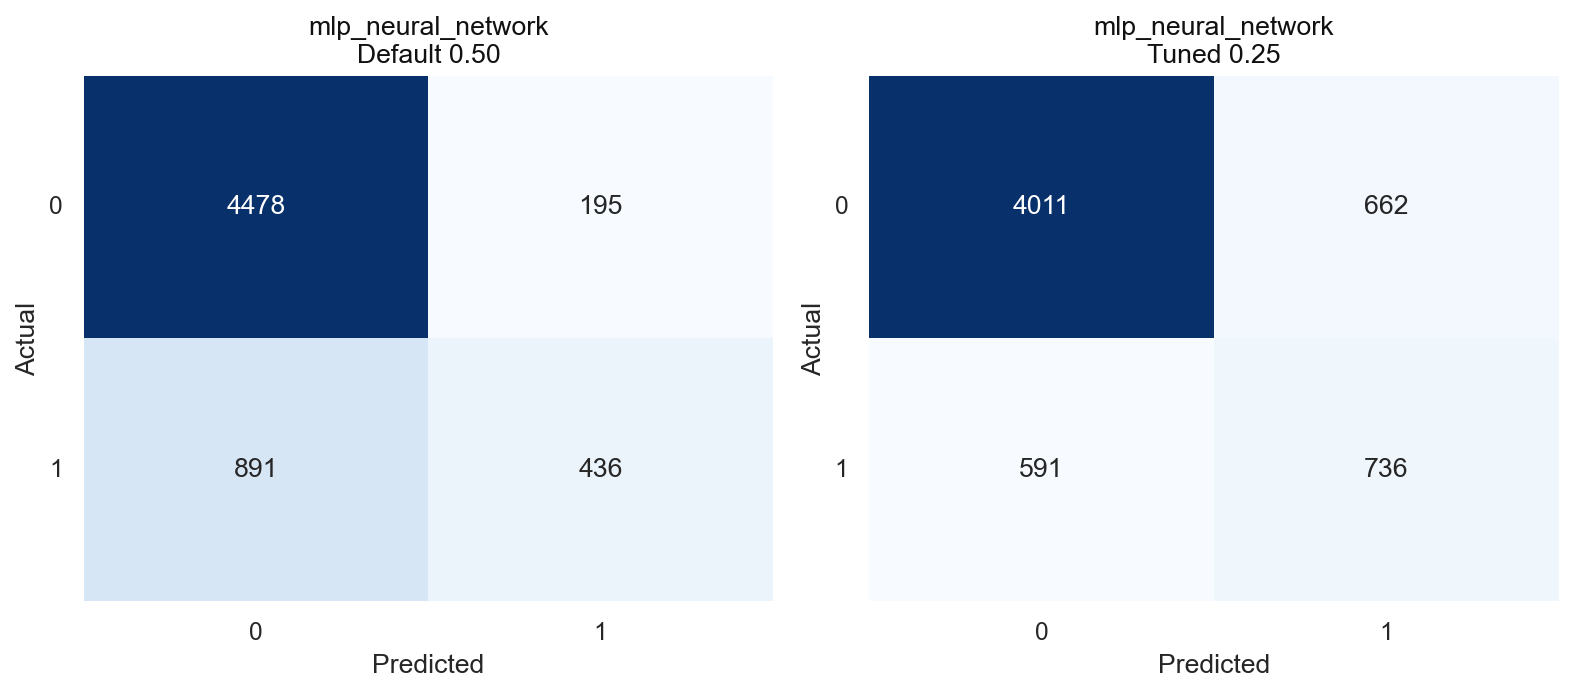

In [40]:
# View saved tuning plots
for name in [
    'hyperparameter_search_pr_auc.png',
    'threshold_tuning_hist_gradient_boosting.png',
    'threshold_tuning_mlp_neural_network.png',
    'tuned_vs_default_threshold_metrics.png',
    'confusion_default_vs_tuned_hist_gradient_boosting.png',
    'confusion_default_vs_tuned_mlp_neural_network.png',
]:
    print(name)
    display(Image(filename=str(STEP5_FIG_DIR / name)))

### Step 5 Decision Summary (Validation Tuning)

- Hyperparameters selected on validation PR-AUC.
- Thresholds selected on validation F1 (`HGB`: `0.57`, `MLP`: `0.25`).
- Decision: lock the leading validation configuration for final evaluation stage.

**Artifacts**: `outputs/metrics/step5_tuning/`, `outputs/figures/step5_tuning/`, `outputs/models/step5_tuning/`

### Step 5 Additional Diagnostics (Validation Only)

These diagnostics extend Step 5 using **validation-only** analysis:
- calibration / reliability behaviour
- error analysis and failure modes (FP/FN patterns)
- training curves / optimisation behaviour

This strengthens evidence while preserving strict test-set integrity.

In [41]:
from src.step5_diagnostics import run_step5_diagnostics

step5_diag_artifacts = run_step5_diagnostics(df, OUTPUTS_DIR)
step5_diag_artifacts

Step5DiagnosticsArtifacts(metrics_dir='/Users/cindylow/Documents/New project 5/outputs/metrics/step5_diagnostics', figures_dir='/Users/cindylow/Documents/New project 5/outputs/figures/step5_diagnostics', summary_path='/Users/cindylow/Documents/New project 5/outputs/metrics/step5_diagnostics/step5_diagnostics_summary.json')

In [42]:
STEP5_DIAG_METRICS_DIR = METRICS_DIR / 'step5_diagnostics'
STEP5_DIAG_FIG_DIR = FIGURES_DIR / 'step5_diagnostics'

diag_summary = json.loads((STEP5_DIAG_METRICS_DIR / 'step5_diagnostics_summary.json').read_text())
segment_pay0 = pd.read_csv(STEP5_DIAG_METRICS_DIR / 'segment_error_rates_by_pay0.csv')
segment_limit = pd.read_csv(STEP5_DIAG_METRICS_DIR / 'segment_error_rates_by_limit_bal_bin.csv')
segment_age = pd.read_csv(STEP5_DIAG_METRICS_DIR / 'segment_error_rates_by_age_bin.csv')
calib_table = pd.read_csv(STEP5_DIAG_METRICS_DIR / 'validation_calibration_table_final_model.csv')
top_fp = pd.read_csv(STEP5_DIAG_METRICS_DIR / 'top_false_positives_final_model_validation.csv')
top_fn = pd.read_csv(STEP5_DIAG_METRICS_DIR / 'top_false_negatives_final_model_validation.csv')

print(json.dumps(diag_summary, indent=2))
display(calib_table)
display(segment_pay0.sort_values('error_rate', ascending=False).head(10))
display(segment_limit)
display(segment_age)
display(top_fp.head(10))
display(top_fn.head(10))

{
  "final_model_name": "hist_gradient_boosting",
  "locked_validation_threshold": 0.57,
  "n_validation": 6000,
  "n_errors": 1238,
  "error_rate": 0.20633333333333334,
  "fp_count": 655,
  "fn_count": 583,
  "top_error_segments_pay0": [
    {
      "PAY_0": 5,
      "n": 5,
      "error_rate": 0.6,
      "fp_rate": 0.6,
      "fn_rate": 0.0,
      "actual_default_rate": 0.4,
      "predicted_positive_rate": 1.0
    },
    {
      "PAY_0": 7,
      "n": 2,
      "error_rate": 0.5,
      "fp_rate": 0.5,
      "fn_rate": 0.0,
      "actual_default_rate": 0.5,
      "predicted_positive_rate": 1.0
    },
    {
      "PAY_0": 8,
      "n": 10,
      "error_rate": 0.5,
      "fp_rate": 0.5,
      "fn_rate": 0.0,
      "actual_default_rate": 0.5,
      "predicted_positive_rate": 1.0
    },
    {
      "PAY_0": 1,
      "n": 731,
      "error_rate": 0.42954856361149113,
      "fp_rate": 0.3857729138166895,
      "fn_rate": 0.04377564979480164,
      "actual_default_rate": 0.3433652530779754,


,mean_predicted_probability,fraction_positive
0,0.128819,0.043333
1,0.195058,0.078333
2,0.255105,0.080000
3,0.304209,0.103333
4,0.354692,0.143333
5,0.403126,0.161667
6,0.457407,0.215000
7,0.550013,0.253731
8,0.692516,0.434783
9,0.861632,0.699499


,PAY_0,n,error_rate,fp_rate,fn_rate,actual_default_rate,predicted_positive_rate
7,5,5,0.600000,0.600000,0.000000,0.400000,1.000000
8,7,2,0.500000,0.500000,0.000000,0.500000,1.000000
9,8,10,0.500000,0.500000,0.000000,0.500000,1.000000
3,1,731,0.429549,0.385773,0.043776,0.343365,0.685363
6,4,15,0.400000,0.333333,0.066667,0.666667,0.933333
4,2,520,0.311538,0.311538,0.000000,0.688462,1.000000
5,3,57,0.298246,0.298246,0.000000,0.701754,1.000000
1,-1,1108,0.188628,0.062274,0.126354,0.169675,0.105596
2,0,2974,0.149966,0.033289,0.116678,0.132818,0.049428
0,-2,578,0.129758,0.020761,0.108997,0.133218,0.044983


,LIMIT_BAL_BIN,n,error_rate,fp_rate,fn_rate,actual_default_rate,predicted_positive_rate
0,<=50k,1536,0.287109,0.178385,0.108724,0.317708,0.387370
1,50k-100k,958,0.223382,0.127349,0.096033,0.260960,0.292276
2,100k-200k,1575,0.196825,0.095873,0.100952,0.196190,0.191111
3,200k-500k,1885,0.141114,0.057294,0.083820,0.143236,0.116711
4,>500k,46,0.152174,0.000000,0.152174,0.217391,0.065217


,AGE_BIN,n,error_rate,fp_rate,fn_rate,actual_default_rate,predicted_positive_rate
0,<=25,731,0.243502,0.138167,0.105335,0.253078,0.285910
1,26-35,2605,0.191171,0.103263,0.087908,0.190403,0.205758
2,36-45,1736,0.201037,0.100230,0.100806,0.229839,0.229263
3,46-55,761,0.227332,0.114323,0.113009,0.266754,0.268068
4,56+,167,0.239521,0.143713,0.095808,0.263473,0.311377


,ID,default payment next month,LIMIT_BAL,AGE,SEX,EDUCATION,MARRIAGE,PAY_0,row_index,y_prob,y_pred,error_type,is_error,LIMIT_BAL_BIN,AGE_BIN
0,293,0,30000,43,1,2,1,3,292,0.909102,1,FP,True,<=50k,36-45
1,26615,0,20000,23,1,2,2,3,26614,0.905586,1,FP,True,<=50k,<=25
2,16310,0,100000,34,2,2,1,3,16309,0.902844,1,FP,True,50k-100k,26-35
3,25249,0,120000,23,2,2,2,3,25248,0.898229,1,FP,True,100k-200k,<=25
4,16594,0,20000,28,1,2,2,3,16593,0.894645,1,FP,True,<=50k,26-35
5,9284,0,240000,41,2,5,1,2,9283,0.887834,1,FP,True,200k-500k,36-45
6,14377,0,30000,47,1,3,1,2,14376,0.887834,1,FP,True,<=50k,46-55
7,4448,0,90000,52,1,2,1,2,4447,0.887834,1,FP,True,50k-100k,46-55
8,10197,0,50000,41,2,2,1,2,10196,0.887737,1,FP,True,<=50k,36-45
9,27049,0,130000,43,1,3,1,2,27048,0.886410,1,FP,True,100k-200k,36-45


,ID,default payment next month,LIMIT_BAL,AGE,SEX,EDUCATION,MARRIAGE,PAY_0,row_index,y_prob,y_pred,error_type,is_error,LIMIT_BAL_BIN,AGE_BIN
0,2561,1,310000,32,2,1,2,-2,2560,0.077075,0,FN,True,200k-500k,26-35
1,1556,1,340000,52,1,1,1,-2,1555,0.084228,0,FN,True,200k-500k,46-55
2,28183,1,360000,33,2,1,2,-1,28182,0.100659,0,FN,True,200k-500k,26-35
3,2250,1,550000,32,2,2,1,0,2249,0.115509,0,FN,True,>500k,26-35
4,25048,1,360000,58,1,2,1,-1,25047,0.116919,0,FN,True,200k-500k,56+
5,5078,1,320000,29,2,2,1,-1,5077,0.116971,0,FN,True,200k-500k,26-35
6,11090,1,240000,41,1,2,1,0,11089,0.118117,0,FN,True,200k-500k,36-45
7,22751,1,350000,32,2,1,1,-1,22750,0.119650,0,FN,True,200k-500k,26-35
8,19550,1,360000,32,2,1,2,0,19549,0.121756,0,FN,True,200k-500k,26-35
9,4321,1,420000,34,2,1,2,-1,4320,0.124417,0,FN,True,200k-500k,26-35


validation_calibration_and_probability_distribution_final_model.png


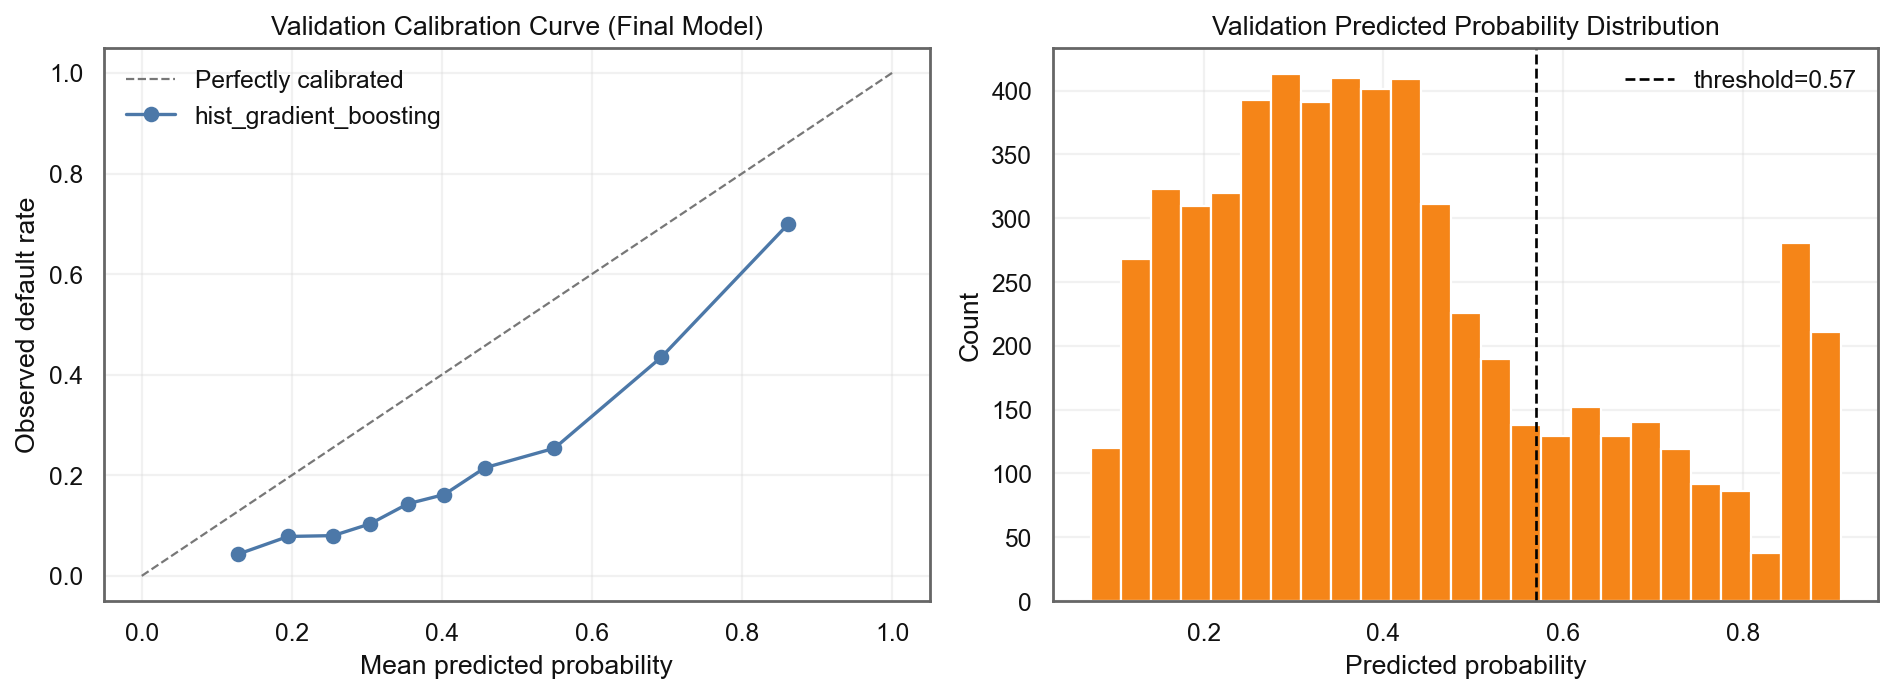

validation_probability_by_error_type_final_model.png


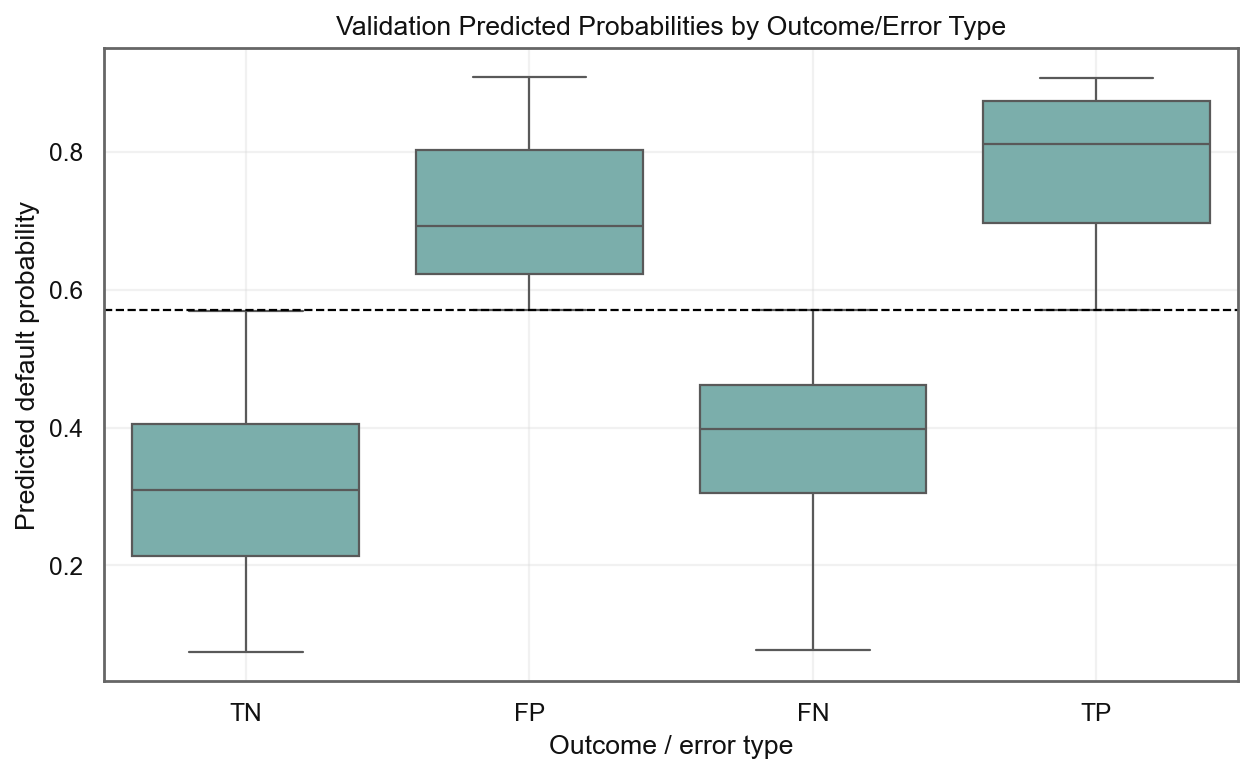

validation_failure_modes_segment_error_rates_final_model.png


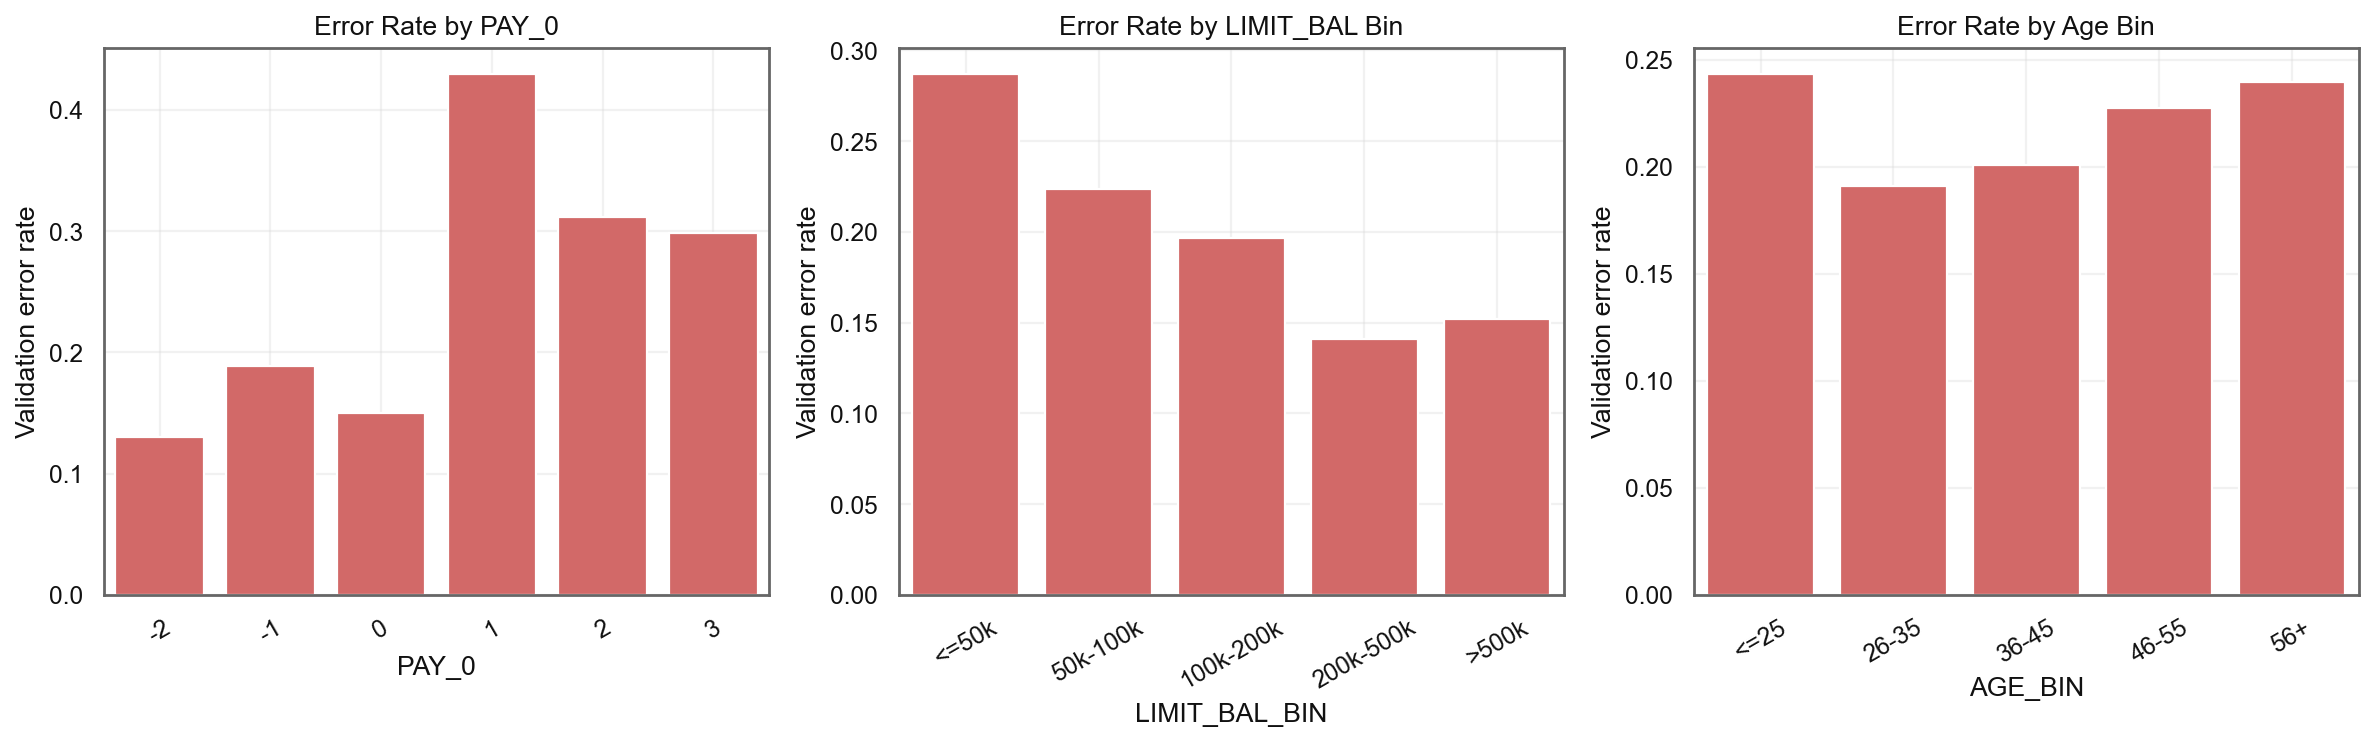

validation_confusion_matrix_final_model_locked_threshold.png


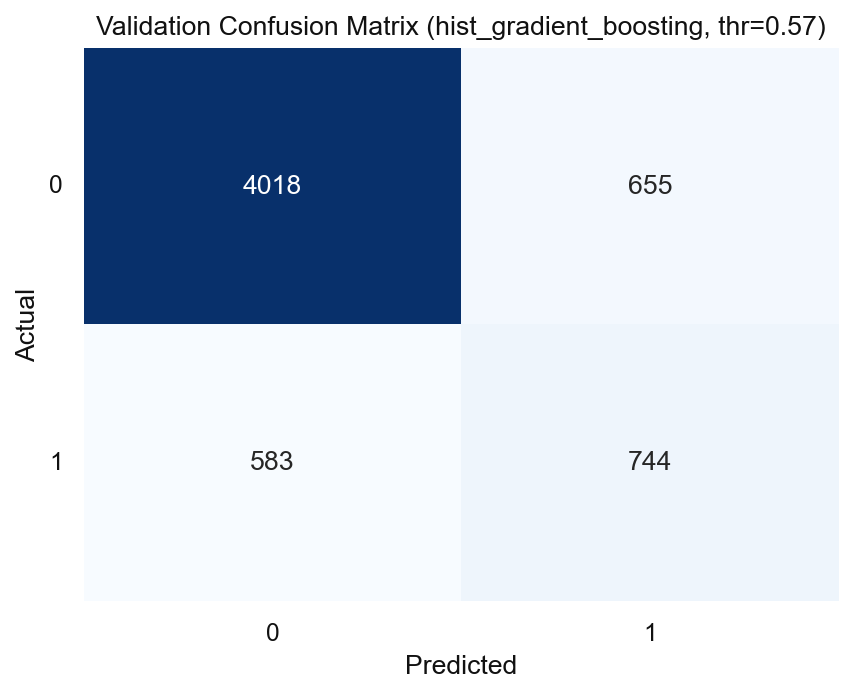

training_curves_mlp_best_tuned_model.png


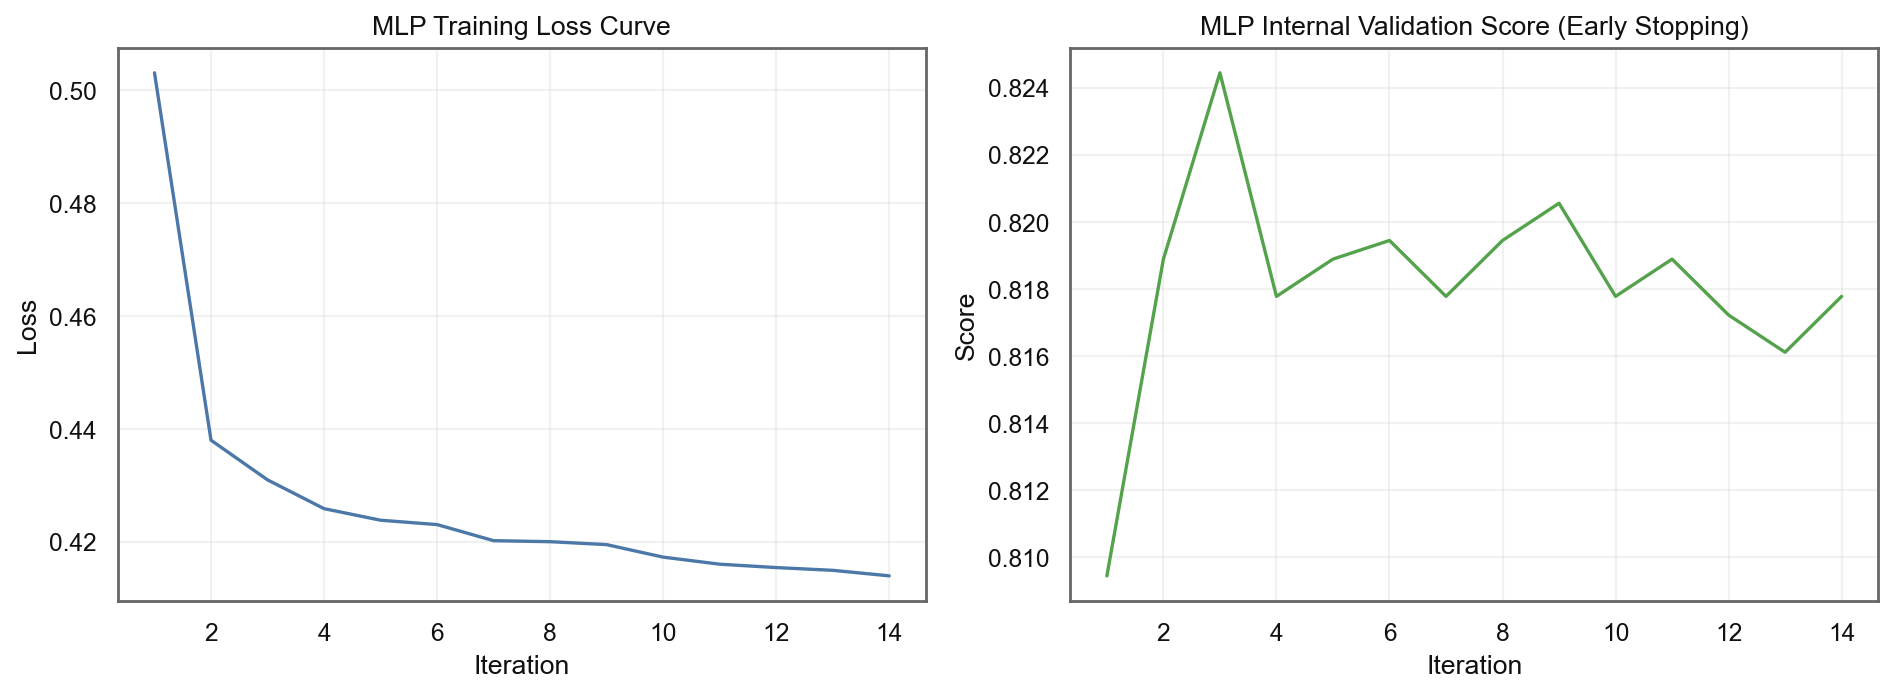

training_curves_hgb_best_tuned_model.png


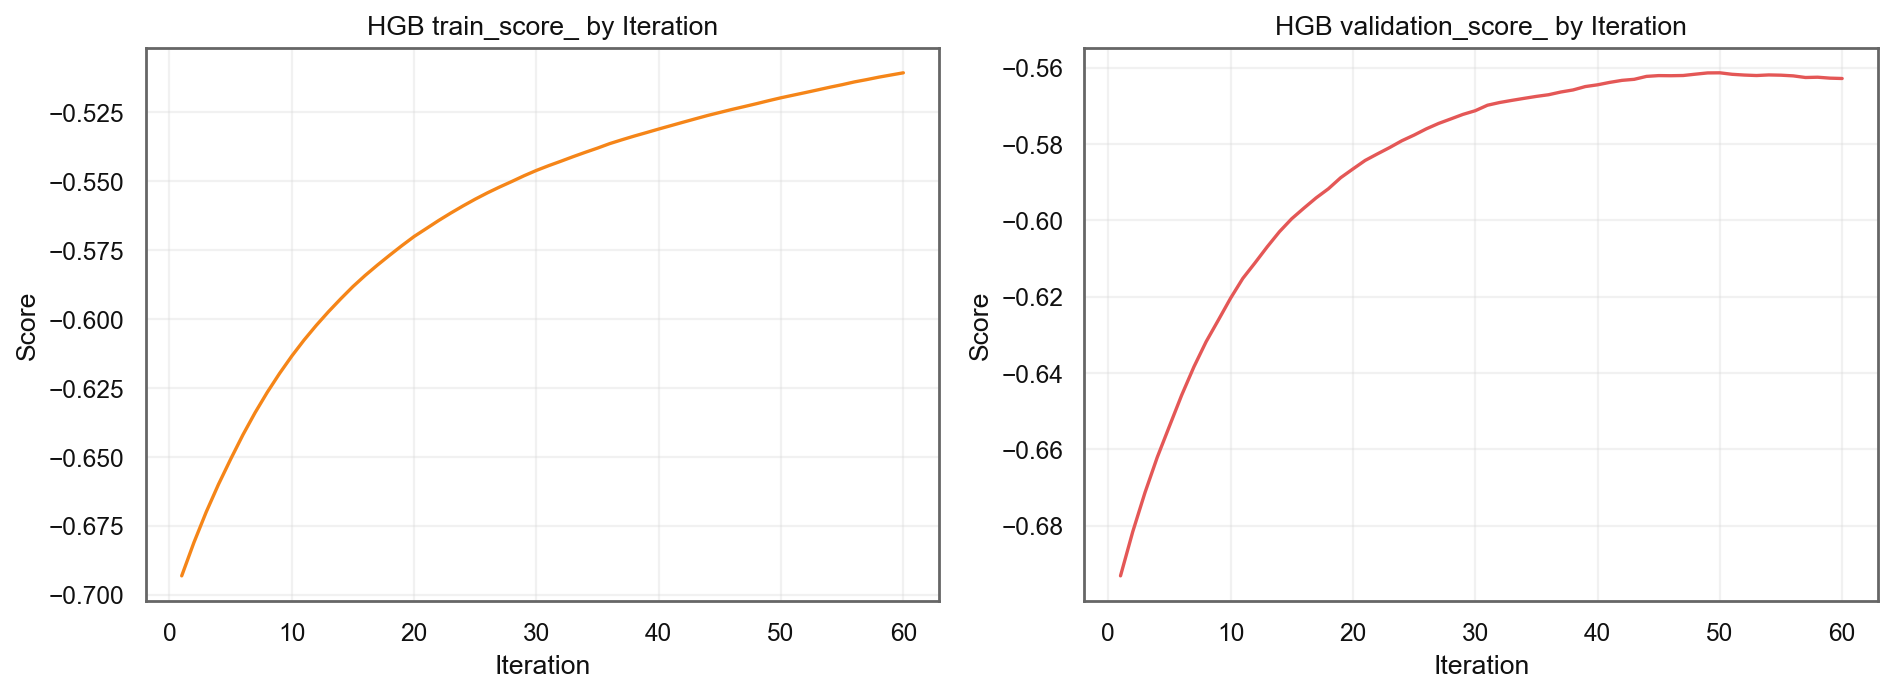

In [43]:
# View validation-only diagnostics plots
for name in [
    'validation_calibration_and_probability_distribution_final_model.png',
    'validation_probability_by_error_type_final_model.png',
    'validation_failure_modes_segment_error_rates_final_model.png',
    'validation_confusion_matrix_final_model_locked_threshold.png',
    'training_curves_mlp_best_tuned_model.png',
    'training_curves_hgb_best_tuned_model.png',
]:
    print(name)
    display(Image(filename=str(STEP5_DIAG_FIG_DIR / name)))

### Step 5 Diagnostics Decision Summary

- Diagnostics indicate useful probability separation with some calibration deviation in extreme bins.
- Error concentration appears in borderline delinquency segments; many mistakes are threshold-adjacent.
- Training dynamics (MLP and HGB) show stable convergence under current settings.

**Agent oversight note**: an earlier agent-generated flow evaluated multiple model/threshold variants on test (test-peeking risk). This was manually caught and corrected by enforcing a strict locked single-evaluation test protocol.

**Artifacts**: `outputs/metrics/step5_diagnostics/`, `outputs/figures/step5_diagnostics/`

## Step 6: Final Model Selection and Locked Evaluation

### Step 6 Goal

- Lock final model configuration (architecture, hyperparameters, threshold) using validation evidence only.
- Refit locked configuration on train+validation and evaluate the test set exactly once.
- Report final out-of-sample metrics and artefacts for the single locked setup.
- Implementation script: `src/step6_final_evaluation.py`.

In [44]:
from src.step6_final_evaluation import run_step6_final_evaluation

step6_artifacts = run_step6_final_evaluation(df, OUTPUTS_DIR, random_state=RANDOM_STATE)
step6_artifacts

Step6Artifacts(metrics_dir='/Users/cindylow/Documents/New project 5/outputs/metrics/step6_final_evaluation', figures_dir='/Users/cindylow/Documents/New project 5/outputs/figures/step6_final_evaluation', models_dir='/Users/cindylow/Documents/New project 5/outputs/models/step6_final_evaluation', final_model_name='hist_gradient_boosting', final_threshold=0.57, test_summary_path='/Users/cindylow/Documents/New project 5/outputs/metrics/step6_final_evaluation/final_test_evaluation_summary.json')

In [45]:
STEP6_METRICS_DIR = METRICS_DIR / 'step6_final_evaluation'
STEP6_FIG_DIR = FIGURES_DIR / 'step6_final_evaluation'
STEP6_MODELS_DIR = MODELS_DIR / 'step6_final_evaluation'

final_test_summary = json.loads((STEP6_METRICS_DIR / 'final_test_evaluation_summary.json').read_text())
final_test_metrics = pd.read_csv(STEP6_METRICS_DIR / 'final_model_test_metrics_locked.csv')

display(final_test_metrics[['model_name','threshold_label','threshold','pr_auc','roc_auc','balanced_accuracy','f1','recall','precision','accuracy']])
print(json.dumps(final_test_summary, indent=2))

,model_name,threshold_label,threshold,pr_auc,roc_auc,balanced_accuracy,f1,recall,precision,accuracy
0,hist_gradient_boosting,locked_threshold_from_validation,0.57,0.550842,0.777532,0.706345,0.538489,0.561417,0.517361,0.787167


{
  "final_model_name": "hist_gradient_boosting",
  "final_model_selected_on": "validation_pr_auc_after_tuning",
  "final_model_hyperparameters": {
    "learning_rate": 0.05,
    "max_iter": 300,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 80,
    "l2_regularization": 0.1
  },
  "threshold_source": "validation_set_f1_maximization",
  "final_threshold": 0.57,
  "fit_data_for_final_model": "train_plus_validation",
  "test_set_size": 6000,
  "test_positive_rate": 0.22116666666666668,
  "test_metrics_at_final_threshold": {
    "model_name": "hist_gradient_boosting",
    "threshold_label": "locked_threshold_from_validation",
    "label": "hist_gradient_boosting | locked threshold from validation",
    "fit_seconds_train_plus_val": 0.7056568339994556,
    "used_sample_weight": true,
    "threshold": 0.57,
    "accuracy": 0.7871666666666667,
    "balanced_accuracy": 0.7063450007264874,
    "precision": 0.5173611111111112,
    "recall": 0.5614167294649586,
    "f1": 0.5384893386338996,
 

test_roc_curve_final_model.png


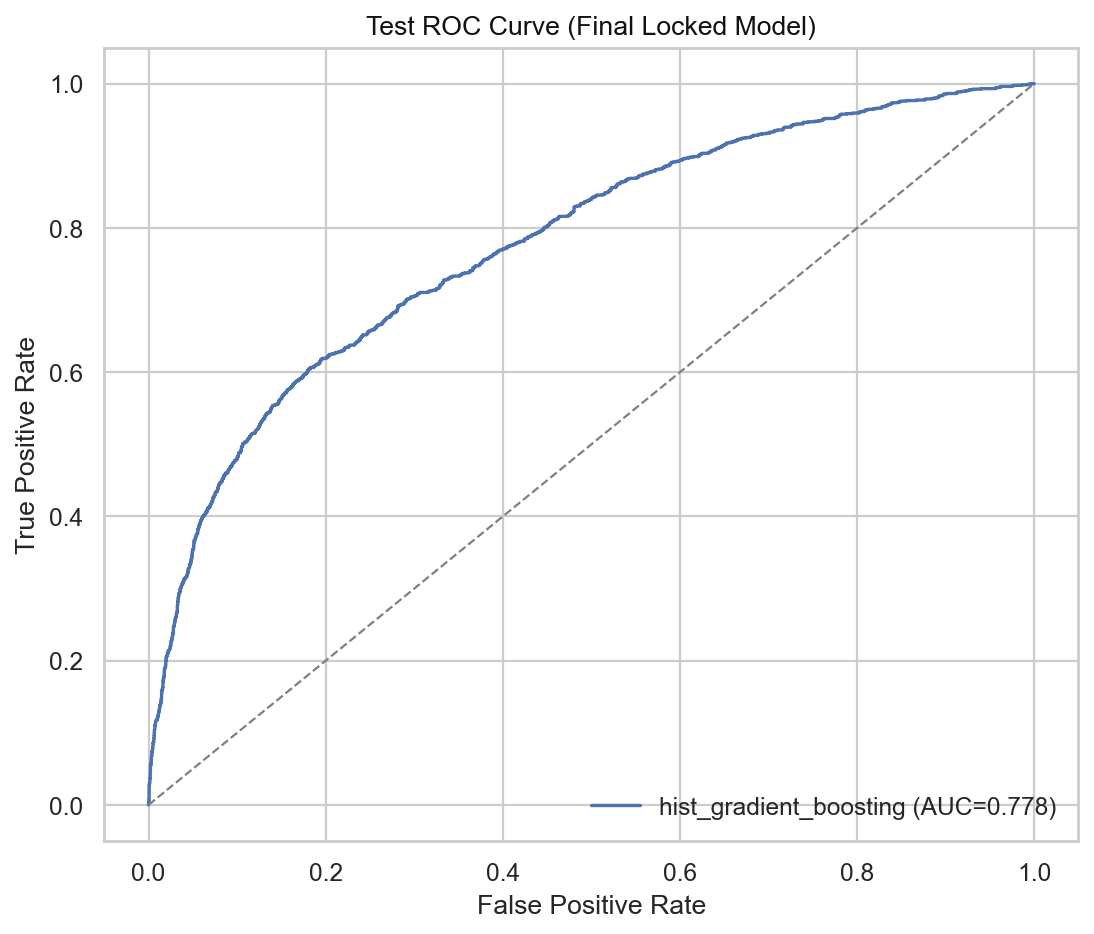

test_pr_curve_final_model.png


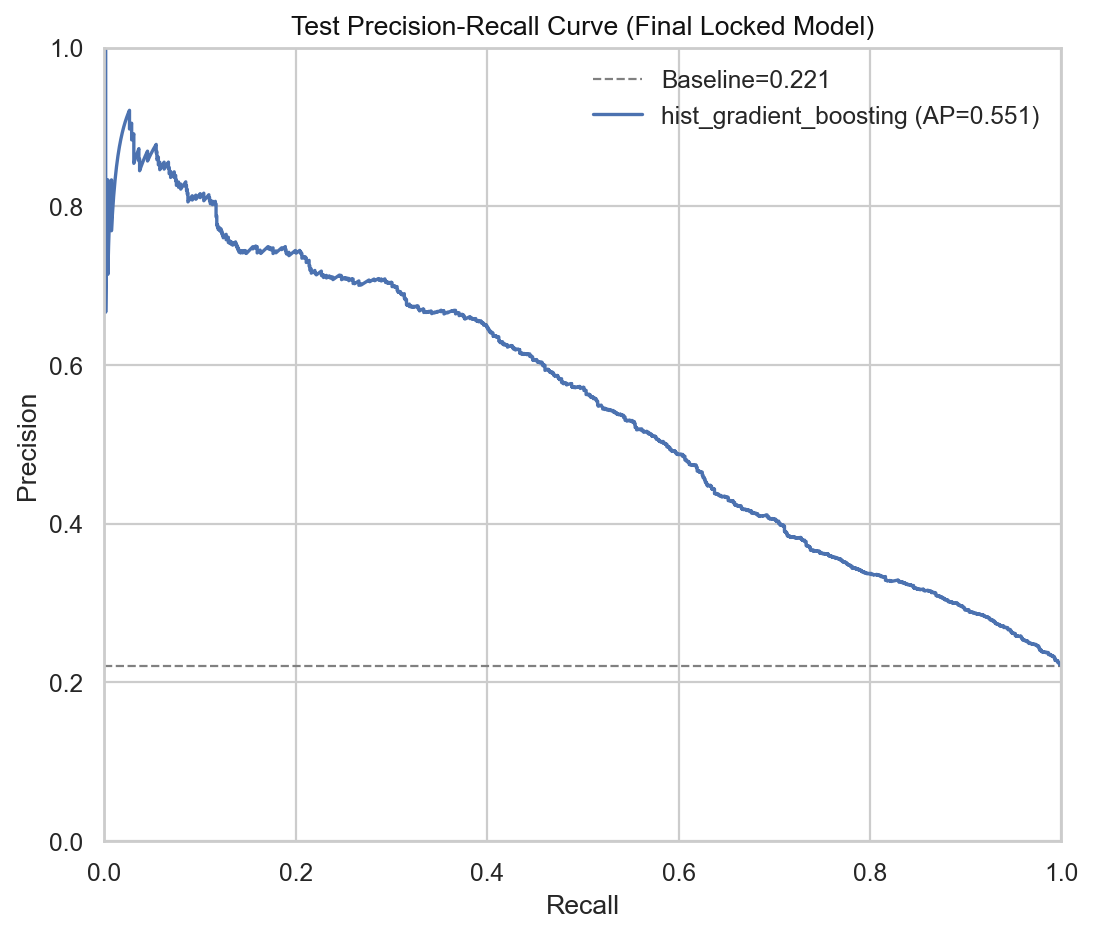

test_confusion_matrix_final_model_locked_threshold.png


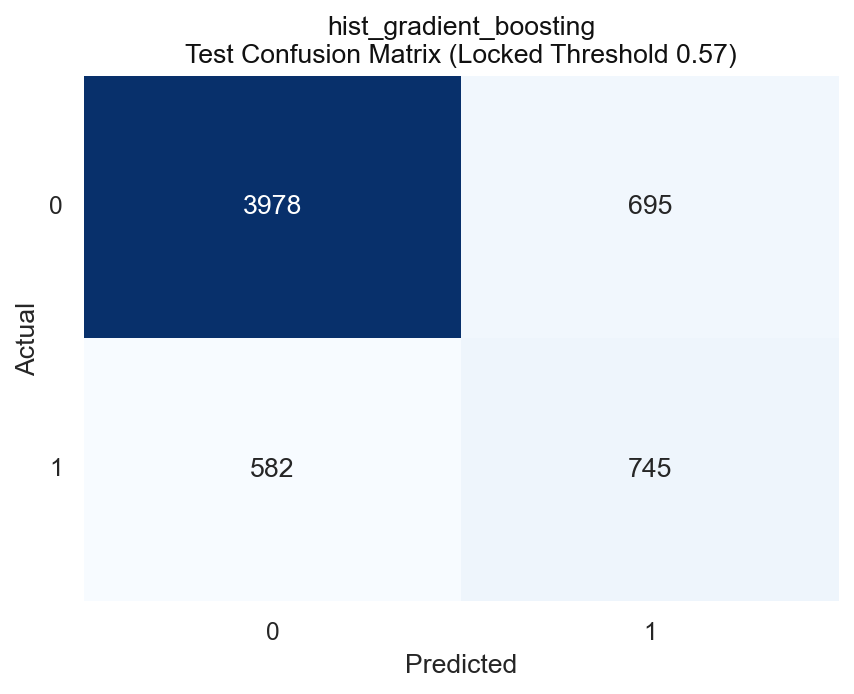

In [46]:
# View saved final-evaluation plots (final locked model only)
for name in [
    'test_roc_curve_final_model.png',
    'test_pr_curve_final_model.png',
    'test_confusion_matrix_final_model_locked_threshold.png',
]:
    print(name)
    display(Image(filename=str(STEP6_FIG_DIR / name)))

### Step 6 Decision Summary (Locked Final Evaluation)

- Locked final model: `HistGradientBoostingClassifier`
- Locked threshold (validation-selected): `0.57`
- Final protocol: refit on train+validation, evaluate test **once**, no test-time model/threshold comparisons

**Result (test)**: `PR-AUC ~0.551`, `ROC-AUC ~0.778`, `F1 ~0.538`, `Balanced Accuracy ~0.706`.

**Artifacts**: `outputs/metrics/step6_final_evaluation/`, `outputs/figures/step6_final_evaluation/`, `outputs/models/step6_final_evaluation/`